🏏 Project: IPL Player Performance Web Scraping

Source: ESPNcricinfo

Period: IPL 2008–2026

Main objective: Scrape player performance season-by-season, then take the data through cleaning, EDA, visualization, insights, and presentation.

In [125]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;template=results;type=batting"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)
print("Length:", len(response.text))

Status Code: 200
Length: 558406


In [126]:
from io import StringIO

tables = pd.read_html(StringIO(response.text))

print("Number of tables:", len(tables))

for i, table in enumerate(tables):
    print("\nTable", i)
    print("Shape:", table.shape)
    print(table.head(3))

Number of tables: 8

Table 0
Shape: (2, 1)
                                     0
0   View overall figures [change view]
1  Ordered by runs scored (descending)

Table 1
Shape: (1, 6)
               0                        1   2                3          4  \
0  Page 1 of 278  Showing 1 - 50 of 13900 NaN  First  Previous  Next Last   

                                         5  
0  Return to query menu Cleared query menu  

Table 2
Shape: (100, 12)
                                              Player  \
0                                         JC Buttler   
1  (Comilla Victorians, Durban's Super Giants, En...   
2                                         KA Pollard   

                                                Span  \
0                                          2009-2026   
1  (Comilla Victorians, Durban's Super Giants, En...   
2                                          2006-2026   

                                                 Mat  \
0                                       

In [127]:
soup=BeautifulSoup(response.text,"html.parser")

for link in soup.find_all("a"):
    text=link.get_text(" ",strip=True)
    href=link.get("href")

    if text=="IPL":
        print("Text:",text)
        print("URL:",href)

Text: IPL
URL: /records/trophy/indian-premier-league-117


In [128]:
url = "https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;template=results;trophy=117;type=batting"

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)
print("Length:", len(response.text))

Status Code: 200
Length: 346683


In [129]:
url

'https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;template=results;trophy=117;type=batting'

In [130]:
from io import StringIO

In [131]:
tables=pd.read_html(StringIO(response.text))
print("Number of tables:",len(tables))

for i,table in enumerate(tables):
    print("\nTable",i)
    print("Shape:",table.shape)
    print(table.head(3))

Number of tables: 8

Table 0
Shape: (3, 1)
                                     0
0   View overall figures [change view]
1         Trophy Indian Premier League
2  Ordered by runs scored (descending)

Table 1
Shape: (1, 6)
              0                      1   2                3          4  \
0  Page 1 of 17  Showing 1 - 50 of 809 NaN  First  Previous  Next Last   

                                         5  
0  Return to query menu Cleared query menu  

Table 2
Shape: (100, 16)
                                              Player  \
0                                            V Kohli   
1  (Royal Challengers Bangalore, Royal Challenger...   
2                                          RG Sharma   

                                                Span  \
0                                          2008-2026   
1  (Royal Challengers Bangalore, Royal Challenger...   
2                                          2008-2026   

                                                 Mat  \
0      

In [132]:
ipl_batting_career = tables[2]

print(ipl_batting_career.head())
print(ipl_batting_career.shape)

                                              Player  \
0                                            V Kohli   
1  (Royal Challengers Bangalore, Royal Challenger...   
2                                          RG Sharma   
3                  (Deccan Chargers, Mumbai Indians)   
4                                           S Dhawan   

                                                Span  \
0                                          2008-2026   
1  (Royal Challengers Bangalore, Royal Challenger...   
2                                          2008-2026   
3                  (Deccan Chargers, Mumbai Indians)   
4                                          2008-2024   

                                                 Mat  \
0                                                283   
1  (Royal Challengers Bangalore, Royal Challenger...   
2                                                281   
3                  (Deccan Chargers, Mumbai Indians)   
4                                             

In [133]:
# Find season-related links/options in the ESPNcricinfo page

soup = BeautifulSoup(response.text, "html.parser")

for link in soup.find_all("a"):
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if "2008" in text or "season" in text.lower():
        print("Text:", text)
        print("URL:", href)

Text: Season view
URL: https://www.cricinfo.com/ci/engine/series/index.html?view=season
Text: By season
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;template=results;trophy=117;type=batting;view=season
Text: Query for 18 Apr 2008 to 31 May 2026
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmax1=31+May+2026;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting
Text: Query for up to 18 Apr 2008
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmax1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting
Text: Query for since 18 Apr 2008
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting
Text: Query for 20 Apr 2008 to 24 May 2026
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmax1=24+May+2026;spanmin1=20+Apr+2008;spanval1=span;template=results;trophy=117;type=b

In [136]:
season_url = "https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;template=results;trophy=117;type=batting;view=season"

season_response = requests.get(season_url, headers=headers)

print("Status Code:", season_response.status_code)
print("Length:", len(season_response.text))

Status Code: 200
Length: 248570


In [138]:
season_tables = pd.read_html(StringIO(season_response.text))

print("Number of tables:", len(season_tables))

for i, table in enumerate(season_tables):
    print("\nTable", i)
    print("Shape:", table.shape)
    print(table.head(3))

Number of tables: 8

Table 0
Shape: (3, 1)
                                     0
0         View by season [change view]
1         Trophy Indian Premier League
2  Ordered by runs scored (descending)

Table 1
Shape: (1, 6)
              0                       1   2                3          4  \
0  Page 1 of 68  Showing 1 - 50 of 3355 NaN  First  Previous  Next Last   

                                         5  
0  Return to query menu Cleared query menu  

Table 2
Shape: (100, 16)
                          Player                            Mat  \
0                        V Kohli                             16   
1  (Royal Challengers Bangalore)  (Royal Challengers Bangalore)   
2                   Shubman Gill                             17   

                            Inns                             NO  \
0                             16                              4   
1  (Royal Challengers Bangalore)  (Royal Challengers Bangalore)   
2                             17         

In [139]:
for i, table in enumerate(season_tables):
    print("Table", i)
    print("Columns:", table.columns.tolist())
    print("Shape:", table.shape)
    print()

Table 0
Columns: [0]
Shape: (3, 1)

Table 1
Columns: [0, 1, 2, 3, 4, 5]
Shape: (1, 6)

Table 2
Columns: ['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Season', 'Unnamed: 15']
Shape: (100, 16)

Table 3
Columns: [0, 1, 2, 3, 4, 5]
Shape: (1, 6)

Table 4
Columns: [0, 1, 2]
Shape: (1, 3)

Table 5
Columns: [0]
Shape: (5, 1)

Table 6
Columns: [0, 1]
Shape: (3, 2)

Table 7
Columns: [0, 1]
Shape: (1, 2)



In [140]:
ipl_batting_season=season_tables[2]
print(ipl_batting_season.head(10))

                          Player                            Mat  \
0                        V Kohli                             16   
1  (Royal Challengers Bangalore)  (Royal Challengers Bangalore)   
2                   Shubman Gill                             17   
3               (Gujarat Titans)               (Gujarat Titans)   
4                     JC Buttler                             17   
5             (Rajasthan Royals)             (Rajasthan Royals)   
6                      DA Warner                             17   
7          (Sunrisers Hyderabad)          (Sunrisers Hyderabad)   
8                 V Sooryavanshi                             16   
9             (Rajasthan Royals)             (Rajasthan Royals)   

                            Inns                             NO  \
0                             16                              4   
1  (Royal Challengers Bangalore)  (Royal Challengers Bangalore)   
2                             17                             

In [141]:
print(ipl_batting_season["Season"].unique())

['2016' '(Royal Challengers Bangalore)' '2023' '(Gujarat Titans)' '2022'
 '(Rajasthan Royals)' '(Sunrisers Hyderabad)' '2026' '2025' '2024'
 '(Royal Challengers Bengaluru)' '2018' '2012' '2013'
 '(Chennai Super Kings)' '(Mumbai Indians)' '2019' '(Delhi Daredevils)'
 '2020/21' '(Kings XI Punjab)' '2014' '(Kolkata Knight Riders)' '2017'
 '2021' '(Lucknow Super Giants)' '(Punjab Kings)' '2009/10'
 '(Delhi Capitals)' '2007/08' '2011']


In [142]:
print(ipl_batting_season[["Player", "Season"]].head(20).to_string(index=False))

                       Player                        Season
                      V Kohli                          2016
(Royal Challengers Bangalore) (Royal Challengers Bangalore)
                 Shubman Gill                          2023
             (Gujarat Titans)              (Gujarat Titans)
                   JC Buttler                          2022
           (Rajasthan Royals)            (Rajasthan Royals)
                    DA Warner                          2016
        (Sunrisers Hyderabad)         (Sunrisers Hyderabad)
               V Sooryavanshi                          2026
           (Rajasthan Royals)            (Rajasthan Royals)
              B Sai Sudharsan                          2025
             (Gujarat Titans)              (Gujarat Titans)
                      V Kohli                          2024
(Royal Challengers Bengaluru) (Royal Challengers Bengaluru)
                KS Williamson                          2018
        (Sunrisers Hyderabad)         (S

In [143]:
print(ipl_batting_season[["Player", "Season"]].tail(20).to_string(index=False))

                 Player                  Season
                SS Iyer                    2025
         (Punjab Kings)          (Punjab Kings)
              AT Rayudu                    2018
  (Chennai Super Kings)   (Chennai Super Kings)
           Ishan Kishan                    2026
  (Sunrisers Hyderabad)   (Sunrisers Hyderabad)
               KL Rahul                    2019
      (Kings XI Punjab)       (Kings XI Punjab)
               KL Rahul                    2026
       (Delhi Capitals)        (Delhi Capitals)
              G Gambhir                    2012
(Kolkata Knight Riders) (Kolkata Knight Riders)
             RD Gaikwad                    2023
  (Chennai Super Kings)   (Chennai Super Kings)
               S Dhawan                    2021
       (Delhi Capitals)        (Delhi Capitals)
             RD Gaikwad                    2024
  (Chennai Super Kings)   (Chennai Super Kings)
                R Parag                    2024
     (Rajasthan Royals)      (Rajasthan 

In [144]:
url_2008 = "https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting"

response_2008 = requests.get(url_2008, headers=headers)

print("Status Code:", response_2008.status_code)
print("Length:", len(response_2008.text))

Status Code: 200
Length: 248810


In [145]:
tables_2008 = pd.read_html(StringIO(response_2008.text))

print("Number of tables:", len(tables_2008))

for i, table in enumerate(tables_2008):
    print("Table", i, "Shape:", table.shape)
    print(table.head(2))

Number of tables: 8
Table 0 Shape: (4, 1)
                                                   0
0                 View overall figures [change view]
1  Start of match date between 18 Apr 2008 and 1 ...
Table 1 Shape: (1, 6)
             0                      1   2                3          4  \
0  Page 1 of 4  Showing 1 - 50 of 163 NaN  First  Previous  Next Last   

                                         5  
0  Return to query menu Cleared query menu  
Table 2 Shape: (100, 15)
              Player                Mat               Inns                 NO  \
0           SE Marsh                 11                 11                  2   
1  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)   

                Runs                 HS                Ave                 BF  \
0                616                115              68.44                441   
1  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)   

                  SR       

In [146]:
ipl_batting_2008 = tables_2008[2].copy()

print(ipl_batting_2008.shape)
print(ipl_batting_2008.columns.tolist())

(100, 15)
['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Unnamed: 14']


In [147]:
print(ipl_batting_2008.head(10).to_string(index=False))

            Player                Mat               Inns                 NO               Runs                 HS                Ave                 BF                 SR                100                 50                  0                 4s                 6s        Unnamed: 14
          SE Marsh                 11                 11                  2                616                115              68.44                441             139.68                  1                  5                  0                 59                 26                NaN
 (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)  (Kings XI Punjab)
         G Gambhir                 14                 14                  1                534                 86              41.07             

In [148]:
seasons = list(range(2008, 2027))

print(seasons)
print("Total seasons:", len(seasons))

[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Total seasons: 19


In [149]:
season_dates = {
    2008: ("18 Apr 2008", "1 Jun 2008"),
    2009: ("18 Apr 2009", "24 May 2009"),
    2010: ("12 Mar 2010", "25 Apr 2010"),
    2011: ("8 Apr 2011", "28 May 2011"),
    2012: ("4 Apr 2012", "27 May 2012"),
    2013: ("3 Apr 2013", "26 May 2013"),
    2014: ("16 Apr 2014", "1 Jun 2014"),
    2015: ("8 Apr 2015", "24 May 2015"),
    2016: ("9 Apr 2016", "29 May 2016"),
    2017: ("5 Apr 2017", "21 May 2017"),
    2018: ("7 Apr 2018", "27 May 2018"),
    2019: ("23 Mar 2019", "12 May 2019"),
    2020: ("19 Sep 2020", "10 Nov 2020"),
    2021: ("9 Apr 2021", "15 Oct 2021"),
    2022: ("26 Mar 2022", "29 May 2022"),
    2023: ("31 Mar 2023", "29 May 2023"),
    2024: ("22 Mar 2024", "26 May 2024"),
    2025: ("22 Mar 2025", "25 May 2025"),
    2026: ("28 Mar 2026", "31 May 2026")
}

print("Total season date ranges:", len(season_dates))
print(season_dates[2008])
print(season_dates[2026])

Total season date ranges: 19
('18 Apr 2008', '1 Jun 2008')
('28 Mar 2026', '31 May 2026')


In [150]:
start_date, end_date = season_dates[2008]

url_2008_auto = (
    "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
    f"class=6;filter=advanced;orderby=runs;"
    f"spanmax1={end_date.replace(' ', '+')};"
    f"spanmin1={start_date.replace(' ', '+')};"
    f"spanval1=span;template=results;trophy=117;type=batting"
)

print(url_2008_auto)

https://stats.espncricinfo.com/ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting


In [151]:
response = requests.get(url_2008_auto, headers=headers)

print("Status Code:", response.status_code)
print("Length:", len(response.text))

Status Code: 200
Length: 248810


In [152]:
tables = pd.read_html(StringIO(response.text))

ipl_2008 = tables[2].copy()

print("Shape:", ipl_2008.shape)
print(ipl_2008.head())

Shape: (100, 15)
               Player                 Mat                Inns  \
0            SE Marsh                  11                  11   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2           G Gambhir                  14                  14   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4       ST Jayasuriya                  14                  14   

                   NO                Runs                  HS  \
0                   2                 616                 115   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2                   1                 534                  86   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4                   2                 514                114*   

                  Ave                  BF                  SR  \
0               68.44                 441              139.68   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2     

In [153]:
batting_data = []

for season in seasons:
    
    start_date, end_date = season_dates[season]
    
    url = (
        "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
        f"class=6;filter=advanced;orderby=runs;"
        f"spanmax1={end_date.replace(' ', '+')};"
        f"spanmin1={start_date.replace(' ', '+')};"
        f"spanval1=span;template=results;trophy=117;type=batting"
    )
    
    response = requests.get(url, headers=headers)
    
    print(f"{season}: Status {response.status_code}")
    
    tables = pd.read_html(StringIO(response.text))
    
    df = tables[2].copy()
    
    batting_data.append(df)

2008: Status 200
2009: Status 200
2010: Status 200
2011: Status 200
2012: Status 200
2013: Status 200
2014: Status 200
2015: Status 200
2016: Status 200
2017: Status 200
2018: Status 200
2019: Status 200
2020: Status 200
2021: Status 200
2022: Status 200
2023: Status 200
2024: Status 200
2025: Status 200
2026: Status 200


In [154]:
print("Number of season datasets:", len(batting_data))

for i, df in enumerate(batting_data):
    print(i, "Shape:", df.shape)

Number of season datasets: 19
0 Shape: (100, 15)
1 Shape: (100, 15)
2 Shape: (100, 15)
3 Shape: (100, 15)
4 Shape: (100, 15)
5 Shape: (100, 15)
6 Shape: (100, 15)
7 Shape: (100, 15)
8 Shape: (100, 15)
9 Shape: (100, 15)
10 Shape: (100, 15)
11 Shape: (100, 15)
12 Shape: (100, 15)
13 Shape: (100, 15)
14 Shape: (100, 15)
15 Shape: (100, 15)
16 Shape: (100, 15)
17 Shape: (100, 15)
18 Shape: (100, 15)


In [155]:
ipl_batting_raw = pd.concat(batting_data, ignore_index=True)

print("Shape:", ipl_batting_raw.shape)
print(ipl_batting_raw.head())

Shape: (1900, 15)
               Player                 Mat                Inns  \
0            SE Marsh                  11                  11   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2           G Gambhir                  14                  14   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4       ST Jayasuriya                  14                  14   

                   NO                Runs                  HS  \
0                   2                 616                 115   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2                   1                 534                  86   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4                   2                 514                114*   

                  Ave                  BF                  SR  \
0               68.44                 441              139.68   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2    

In [156]:
print(ipl_batting_raw.columns.tolist())

['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Unnamed: 14']


In [157]:
batting_data_with_season = []

for season, df in zip(seasons, batting_data):
    
    df = df.copy()
    df["Season"] = season
    
    batting_data_with_season.append(df)

print("Number of datasets:", len(batting_data_with_season))
print(batting_data_with_season[0][["Player", "Season"]].head())

Number of datasets: 19
               Player  Season
0            SE Marsh    2008
1   (Kings XI Punjab)    2008
2           G Gambhir    2008
3  (Delhi Daredevils)    2008
4       ST Jayasuriya    2008


In [158]:
ipl_batting_raw_with_season = pd.concat(
    batting_data_with_season,
    ignore_index=True
)

print("Shape:", ipl_batting_raw_with_season.shape)
print(ipl_batting_raw_with_season[["Player", "Season"]].head(10))

Shape: (1900, 16)
               Player  Season
0            SE Marsh    2008
1   (Kings XI Punjab)    2008
2           G Gambhir    2008
3  (Delhi Daredevils)    2008
4       ST Jayasuriya    2008
5    (Mumbai Indians)    2008
6           SR Watson    2008
7  (Rajasthan Royals)    2008
8            GC Smith    2008
9  (Rajasthan Royals)    2008


In [159]:
print(ipl_batting_raw_with_season.columns.tolist())

['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Unnamed: 14', 'Season']


In [160]:
print(ipl_batting_raw_with_season.head())

               Player                 Mat                Inns  \
0            SE Marsh                  11                  11   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2           G Gambhir                  14                  14   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4       ST Jayasuriya                  14                  14   

                   NO                Runs                  HS  \
0                   2                 616                 115   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2                   1                 534                  86   
3  (Delhi Daredevils)  (Delhi Daredevils)  (Delhi Daredevils)   
4                   2                 514                114*   

                  Ave                  BF                  SR  \
0               68.44                 441              139.68   
1   (Kings XI Punjab)   (Kings XI Punjab)   (Kings XI Punjab)   
2               41.07  

In [161]:
ipl_batting_raw_with_season

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 14,Season
0,SE Marsh,11,11,2,616,115,68.44,441,139.68,1,5,0,59,26,NaN,2008
1,(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),2008
2,G Gambhir,14,14,1,534,86,41.07,379,140.89,0,5,0,68,8,NaN,2008
3,(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),2008
4,ST Jayasuriya,14,14,2,514,114*,42.83,309,166.34,1,2,0,57,31,NaN,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),2026
1896,MP Stoinis,13,9,3,216,62*,36,120,180,0,1,1,23,11,NaN,2026
1897,(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),2026
1898,A Badoni,10,10,0,215,54,21.5,141,152.48,0,1,3,23,9,NaN,2026


In [162]:
print(ipl_batting_raw_with_season["Player"].head(20))

0                  SE Marsh
1         (Kings XI Punjab)
2                 G Gambhir
3        (Delhi Daredevils)
4             ST Jayasuriya
5          (Mumbai Indians)
6                 SR Watson
7        (Rajasthan Royals)
8                  GC Smith
9        (Rajasthan Royals)
10             AC Gilchrist
11        (Deccan Chargers)
12                YK Pathan
13       (Rajasthan Royals)
14                 SK Raina
15    (Chennai Super Kings)
16                 MS Dhoni
17    (Chennai Super Kings)
18                 V Sehwag
19       (Delhi Daredevils)
Name: Player, dtype: object


In [163]:
team_rows = ipl_batting_raw_with_season[
    ipl_batting_raw_with_season["Player"].astype(str).str.startswith("(")
]

print("Team rows:", len(team_rows))

Team rows: 950


In [164]:
player_rows = ipl_batting_raw_with_season[
    ~ipl_batting_raw_with_season["Player"].astype(str).str.startswith("(")
]

print("Player rows:", len(player_rows))

Player rows: 950


In [165]:
print(batting_data[0].shape)

(100, 15)


In [166]:
print(batting_data[0]["Player"].tail(10))

90               KD Karthik
91       (Delhi Daredevils)
92                 S Vidyut
93    (Chennai Super Kings)
94                RA Jadeja
95       (Rajasthan Royals)
96                IK Pathan
97        (Kings XI Punjab)
98             Kamran Akmal
99       (Rajasthan Royals)
Name: Player, dtype: object


In [167]:
soup = BeautifulSoup(response_2008.text, "html.parser")

for link in soup.find_all("a"):
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if text.lower() in ["next", "2", "3"]:
        print("Text:", text)
        print("URL:", href)

Text: Next
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=2;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting
Text: Next
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=2;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting


In [168]:
url_2008_page2 = (
    "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
    "class=6;filter=advanced;orderby=runs;"
    "page=2;"
    "spanmax1=1+Jun+2008;"
    "spanmin1=18+Apr+2008;"
    "spanval1=span;"
    "template=results;trophy=117;type=batting"
)

response_page2 = requests.get(url_2008_page2, headers=headers)

print("Status Code:", response_page2.status_code)

Status Code: 200


In [169]:
tables_page2 = pd.read_html(StringIO(response_page2.text))

df_page2 = tables_page2[2].copy()

print("Shape:", df_page2.shape)
print(df_page2["Player"].head(10))

Shape: (100, 15)
0                      MF Maharoof
1               (Delhi Daredevils)
2                    Misbah-ul-Haq
3    (Royal Challengers Bangalore)
4                         W Jaffer
5    (Royal Challengers Bangalore)
6                         CL White
7    (Royal Challengers Bangalore)
8                          P Kumar
9    (Royal Challengers Bangalore)
Name: Player, dtype: object


In [170]:
soup_2008 = BeautifulSoup(response_2008.text, "html.parser")

page_numbers = []

for link in soup_2008.find_all("a"):
    text = link.get_text(" ", strip=True)
    href = link.get("href", "")

    if "page=" in href and text.isdigit():
        page_numbers.append(int(text))

print("Pages found:", sorted(set(page_numbers)))

Pages found: []


In [171]:
for link in soup_2008.find_all("a"):
    href = link.get("href", "")
    
    if "page=" in href:
        print("Text:", link.get_text(" ", strip=True))
        print("URL:", href)
        print()

Text: Next
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=2;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting

Text: Last
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=4;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting

Text: Next
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=2;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting

Text: Last
URL: /ci/engine/stats/index.html?class=6;filter=advanced;orderby=runs;page=4;spanmax1=1+Jun+2008;spanmin1=18+Apr+2008;spanval1=span;template=results;trophy=117;type=batting



In [172]:
from urllib.parse import urljoin

base_url = "https://stats.espncricinfo.com"

# Get the 2008 page 1 HTML
soup = BeautifulSoup(response_2008.text, "html.parser")

# Find the "Last" page
last_page = 1

for link in soup.find_all("a"):
    text = link.get_text(" ", strip=True)
    href = link.get("href", "")
    
    if text == "Last" and "page=" in href:
        last_page = int(href.split("page=")[1].split(";")[0])

print("Total pages in 2008:", last_page)

Total pages in 2008: 4


In [173]:
all_pages_2008 = []

for page in range(1, last_page + 1):

    url = (
        "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
        "class=6;filter=advanced;orderby=runs;"
        f"page={page};"
        "spanmax1=1+Jun+2008;"
        "spanmin1=18+Apr+2008;"
        "spanval1=span;"
        "template=results;trophy=117;type=batting"
    )

    response = requests.get(url, headers=headers)

    print(f"Page {page}: Status {response.status_code}")

    tables = pd.read_html(StringIO(response.text))

    df = tables[2].copy()

    all_pages_2008.append(df)

print("Number of pages scraped:", len(all_pages_2008))

Page 1: Status 200
Page 2: Status 200
Page 3: Status 200
Page 4: Status 200
Number of pages scraped: 4


In [174]:
ipl_batting_2008 = pd.concat(
    all_pages_2008,
    ignore_index=True
)

print("2008 shape:", ipl_batting_2008.shape)

2008 shape: (326, 15)


In [177]:
all_season_data = []

for season in seasons:

    start_date, end_date = season_dates[season]

    # Page 1 URL
    url = (
        "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
        "class=6;filter=advanced;orderby=runs;"
        f"spanmax1={end_date.replace(' ', '+')};"
        f"spanmin1={start_date.replace(' ', '+')};"
        "spanval1=span;"
        "template=results;trophy=117;type=batting"
    )

    response = requests.get(url, headers=headers)

    print(f"\nSeason {season}: Status {response.status_code}")

    # Find total number of pages
    soup = BeautifulSoup(response.text, "html.parser")

    last_page = 1

    for link in soup.find_all("a"):
        text = link.get_text(" ", strip=True)
        href = link.get("href", "")

        if text == "Last" and "page=" in href:
            last_page = int(
                href.split("page=")[1].split(";")[0]
            )

    print(f"Total pages: {last_page}")

    # Scrape every page
    for page in range(1, last_page + 1):

        page_url = (
            "https://stats.espncricinfo.com/ci/engine/stats/index.html?"
            "class=6;filter=advanced;orderby=runs;"
            f"page={page};"
            f"spanmax1={end_date.replace(' ', '+')};"
            f"spanmin1={start_date.replace(' ', '+')};"
            "spanval1=span;"
            "template=results;trophy=117;type=batting"
        )

        page_response = requests.get(page_url, headers=headers)

        tables = pd.read_html(StringIO(page_response.text))

        df = tables[2].copy()

        df["Season"] = season

        all_season_data.append(df)

        print(f"  Page {page}: {len(df)} rows")


Season 2008: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 26 rows

Season 2009: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 30 rows

Season 2010: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 62 rows

Season 2011: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 98 rows

Season 2012: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 80 rows

Season 2013: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 96 rows

Season 2014: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  Page 4: 4 rows

Season 2015: Status 200
Total pages: 3
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 90 rows

Season 2016: Status 200
Total pages: 4
  Page 1: 100 rows
  Page 2: 100 rows
  Page 3: 100 rows
  P

In [178]:
ipl_batting_raw_all = pd.concat(
    all_season_data,
    ignore_index=True
)

print("Final raw shape:", ipl_batting_raw_all.shape)

Final raw shape: (6694, 16)


In [179]:
ipl_batting_raw_all

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 14,Season
0,SE Marsh,11,11,2,616,115,68.44,441,139.68,1,5,0,59,26,NaN,2008
1,(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),(Kings XI Punjab),2008
2,G Gambhir,14,14,1,534,86,41.07,379,140.89,0,5,0,68,8,NaN,2008
3,(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),(Delhi Daredevils),2008
4,ST Jayasuriya,14,14,2,514,114*,42.83,309,166.34,1,2,0,57,31,NaN,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6689,(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),(Punjab Kings),2026
6690,T Vijay,1,-,-,-,-,-,-,-,-,-,-,-,-,NaN,2026
6691,(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),(Delhi Capitals),2026
6692,Yash Raj Punja,8,-,-,-,-,-,-,-,-,-,-,-,-,NaN,2026


In [180]:
print(ipl_batting_raw_all.shape)

(6694, 16)


In [181]:
print(ipl_batting_raw_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6694 entries, 0 to 6693
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Player       6694 non-null   object
 1   Mat          6694 non-null   object
 2   Inns         6694 non-null   object
 3   NO           6694 non-null   object
 4   Runs         6694 non-null   object
 5   HS           6694 non-null   object
 6   Ave          6694 non-null   object
 7   BF           6694 non-null   object
 8   SR           6694 non-null   object
 9   100          6694 non-null   object
 10  50           6694 non-null   object
 11  0            6694 non-null   object
 12  4s           6694 non-null   object
 13  6s           6694 non-null   object
 14  Unnamed: 14  3347 non-null   object
 15  Season       6694 non-null   int64 
dtypes: int64(1), object(15)
memory usage: 836.9+ KB
None


Check the number of rows per season

In [182]:
print(
    ipl_batting_raw_all["Season"]
    .value_counts()
    .sort_index()
)

Season
2008    326
2009    330
2010    362
2011    398
2012    380
2013    396
2014    304
2015    290
2016    318
2017    322
2018    298
2019    324
2020    302
2021    336
2022    380
2023    418
2024    416
2025    390
2026    404
Name: count, dtype: int64


In [183]:
#check for the duplicates
print("Duplicate Rows:",ipl_batting_raw_all.duplicated().sum())

Duplicate Rows: 3181


In [184]:
duplicate_rows = ipl_batting_raw_all[
    ipl_batting_raw_all.duplicated(keep=False)
]

print("Rows involved in duplicates:", len(duplicate_rows))

print(
    duplicate_rows[
        ["Player", "Season", "Runs", "Mat"]
    ].head(20)
)

Rows involved in duplicates: 3347
                           Player  Season                           Runs  \
1               (Kings XI Punjab)    2008              (Kings XI Punjab)   
3              (Delhi Daredevils)    2008             (Delhi Daredevils)   
5                (Mumbai Indians)    2008               (Mumbai Indians)   
7              (Rajasthan Royals)    2008             (Rajasthan Royals)   
9              (Rajasthan Royals)    2008             (Rajasthan Royals)   
11              (Deccan Chargers)    2008              (Deccan Chargers)   
13             (Rajasthan Royals)    2008             (Rajasthan Royals)   
15          (Chennai Super Kings)    2008          (Chennai Super Kings)   
17          (Chennai Super Kings)    2008          (Chennai Super Kings)   
19             (Delhi Daredevils)    2008             (Delhi Daredevils)   
21              (Deccan Chargers)    2008              (Deccan Chargers)   
23  (Royal Challengers Bangalore)    2008  (Royal Chal

In [185]:
player_rows = ipl_batting_raw_all[
    ~ipl_batting_raw_all["Player"].astype(str).str.startswith("(")
]

print("Player rows:", len(player_rows))

print(
    "Exact duplicate player rows:",
    player_rows.duplicated().sum()
)

Player rows: 3347
Exact duplicate player rows: 0


In [186]:
missing_values=ipl_batting_raw_all.isnull().sum()
print(missing_values)

Player            0
Mat               0
Inns              0
NO                0
Runs              0
HS                0
Ave               0
BF                0
SR                0
100               0
50                0
0                 0
4s                0
6s                0
Unnamed: 14    3347
Season            0
dtype: int64


In [187]:
print(ipl_batting_raw_all["Unnamed: 14"].value_counts(dropna=False).head(20))

Unnamed: 14
NaN                              3347
(Mumbai Indians)                  383
(Kolkata Knight Riders)           370
(Rajasthan Royals)                348
(Royal Challengers Bangalore)     333
(Chennai Super Kings)             318
(Sunrisers Hyderabad)             278
(Kings XI Punjab)                 264
(Delhi Daredevils)                225
(Delhi Capitals)                  166
(Punjab Kings)                    123
(Lucknow Super Giants)            104
(Deccan Chargers)                 103
(Gujarat Titans)                   96
(Pune Warriors)                    74
(Royal Challengers Bengaluru)      56
(Gujarat Lions)                    43
(Rising Pune Supergiants)          23
(Rising Pune Supergiant)           20
(Kochi Tuskers Kerala)             20
Name: count, dtype: int64


In [188]:
print(ipl_batting_raw_all[["Player", "Unnamed: 14"]].head(20))

                   Player            Unnamed: 14
0                SE Marsh                    NaN
1       (Kings XI Punjab)      (Kings XI Punjab)
2               G Gambhir                    NaN
3      (Delhi Daredevils)     (Delhi Daredevils)
4           ST Jayasuriya                    NaN
5        (Mumbai Indians)       (Mumbai Indians)
6               SR Watson                    NaN
7      (Rajasthan Royals)     (Rajasthan Royals)
8                GC Smith                    NaN
9      (Rajasthan Royals)     (Rajasthan Royals)
10           AC Gilchrist                    NaN
11      (Deccan Chargers)      (Deccan Chargers)
12              YK Pathan                    NaN
13     (Rajasthan Royals)     (Rajasthan Royals)
14               SK Raina                    NaN
15  (Chennai Super Kings)  (Chennai Super Kings)
16               MS Dhoni                    NaN
17  (Chennai Super Kings)  (Chennai Super Kings)
18               V Sehwag                    NaN
19     (Delhi Darede

In [189]:
pd.set_option("display.max_columns", None)

print(ipl_batting_raw_all.head(30))

                           Player                            Mat  \
0                        SE Marsh                             11   
1               (Kings XI Punjab)              (Kings XI Punjab)   
2                       G Gambhir                             14   
3              (Delhi Daredevils)             (Delhi Daredevils)   
4                   ST Jayasuriya                             14   
5                (Mumbai Indians)               (Mumbai Indians)   
6                       SR Watson                             15   
7              (Rajasthan Royals)             (Rajasthan Royals)   
8                        GC Smith                             11   
9              (Rajasthan Royals)             (Rajasthan Royals)   
10                   AC Gilchrist                             14   
11              (Deccan Chargers)              (Deccan Chargers)   
12                      YK Pathan                             16   
13             (Rajasthan Royals)             (R

In [190]:
dash_counts = (ipl_batting_raw_all == "-").sum()

print(dash_counts)

Player           0
Mat              0
Inns           366
NO             366
Runs           366
HS             366
Ave            692
BF             366
SR             396
100            366
50             366
0              366
4s             366
6s             366
Unnamed: 14      0
Season           0
dtype: int64


In [191]:
hs_star_count = ipl_batting_raw_all["HS"].astype(str).str.contains(r"\*").sum()

print("HS values containing *:", hs_star_count)

HS values containing *: 1217


In [192]:
print(
    ipl_batting_raw_all[
        ipl_batting_raw_all["HS"].astype(str).str.contains(r"\*")
    ][["Player", "HS", "Season"]].head(20)
)

              Player    HS  Season
4      ST Jayasuriya  114*    2008
6          SR Watson   76*    2008
10      AC Gilchrist  109*    2008
14          SK Raina   55*    2008
18          V Sehwag   94*    2008
20         RG Sharma   76*    2008
22          R Dravid   75*    2008
26          S Dhawan   68*    2008
40   Y Venugopal Rao   71*    2008
44        MV Boucher   50*    2008
48          AM Nayar   45*    2008
60       BB McCullum  158*    2008
64  DPMD Jayawardene   45*    2008
66          DJ Bravo   64*    2008
68            M Kaif   34*    2008
70        MEK Hussey  116*    2008
78         A Symonds  117*    2008
80           WP Saha   59*    2008
84     LA Pomersbach   79*    2008
90        KD Karthik   56*    2008


In [193]:
#Check the data types of the player records
player_rows = ipl_batting_raw_all[
    ~ipl_batting_raw_all["Player"].astype(str).str.startswith("(")
].copy()

print(player_rows.dtypes)

Player         object
Mat            object
Inns           object
NO             object
Runs           object
HS             object
Ave            object
BF             object
SR             object
100            object
50             object
0              object
4s             object
6s             object
Unnamed: 14    object
Season          int64
dtype: object


In [194]:
print(player_rows.head())

          Player Mat Inns NO Runs    HS    Ave   BF      SR 100 50  0  4s  6s  \
0       SE Marsh  11   11  2  616   115  68.44  441  139.68   1  5  0  59  26   
2      G Gambhir  14   14  1  534    86  41.07  379  140.89   0  5  0  68   8   
4  ST Jayasuriya  14   14  2  514  114*  42.83  309  166.34   1  2  0  57  31   
6      SR Watson  15   15  5  472   76*   47.2  311  151.76   0  4  1  46  19   
8       GC Smith  11   11  2  441    91     49  362  121.82   0  3  0  54   8   

  Unnamed: 14  Season  
0         NaN    2008  
2         NaN    2008  
4         NaN    2008  
6         NaN    2008  
8         NaN    2008  


In [195]:
#Check Player + Season duplicates
player_season_duplicates = player_rows.duplicated(
    subset=["Player", "Season"]
).sum()

print("Duplicate Player-Season records:", player_season_duplicates)

Duplicate Player-Season records: 1


In [196]:
unique_players = player_rows["Player"].nunique()

print("Unique players:", unique_players)

Unique players: 805


In [197]:
print(player_rows["Player"].value_counts().head(20))

Player
MK Pandey     19
RG Sharma     19
V Kohli       19
AM Rahane     18
RA Jadeja     18
MS Dhoni      18
S Dhawan      17
KD Karthik    17
WP Saha       17
JD Unadkat    17
A Mishra      16
R Ashwin      16
PP Chawla     16
B Kumar       16
SP Narine     15
I Sharma      15
RV Uthappa    15
DA Miller     15
DA Warner     15
MA Agarwal    15
Name: count, dtype: int64


In [198]:
print("Raw dataset shape:", ipl_batting_raw_all.shape)
print("Player dataset shape:", player_rows.shape)
print("Unique players:", player_rows["Player"].nunique())

Raw dataset shape: (6694, 16)
Player dataset shape: (3347, 16)
Unique players: 805


In [200]:
player_record_counts = player_rows["Player"].value_counts()
print(player_record_counts.describe())

count    805.000000
mean       4.157764
std        3.818156
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       19.000000
Name: count, dtype: float64


In [201]:
print(player_record_counts.value_counts().sort_index())

count
1     255
2     121
3      90
4      77
5      52
6      37
7      39
8      24
9      22
10     18
11     19
12      9
13     11
14     11
15      6
16      4
17      4
18      3
19      3
Name: count, dtype: int64


In [202]:
#Check season coverage
season_player_counts = player_rows["Season"].value_counts().sort_index()

print(season_player_counts)

Season
2008    163
2009    165
2010    181
2011    199
2012    190
2013    198
2014    152
2015    145
2016    159
2017    161
2018    149
2019    162
2020    151
2021    168
2022    190
2023    209
2024    208
2025    195
2026    202
Name: count, dtype: int64


In [203]:
print("Number of seasons:", player_rows["Season"].nunique())
print("Seasons:", sorted(player_rows["Season"].unique()))

Number of seasons: 19
Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [204]:
print("Blank player names:", (player_rows["Player"].str.strip() == "").sum())

print("\nPlayer name length:")
print(player_rows["Player"].str.len().describe())

Blank player names: 0

Player name length:
count    3347.000000
mean        9.755901
std         2.455191
min         5.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        23.000000
Name: Player, dtype: float64


Data Cleaning.

In [205]:
ipl_batting_clean = ipl_batting_raw_all[
    ~ipl_batting_raw_all["Player"].astype(str).str.startswith("(")
].copy()

print("Before cleaning:", len(ipl_batting_raw_all))
print("After removing team rows:", len(ipl_batting_clean))

Before cleaning: 6694
After removing team rows: 3347


In [206]:
print(ipl_batting_clean.columns.tolist())

['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Unnamed: 14', 'Season']


In [207]:
ipl_batting_clean = ipl_batting_clean.drop(columns=["Unnamed: 14"])

print(ipl_batting_clean.columns.tolist())
print("Shape:", ipl_batting_clean.shape)

['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s', 'Season']
Shape: (3347, 15)


In [208]:
ipl_batting_clean=ipl_batting_clean.rename(columns={
    "Player":"Player",
    "Mat":"Matches",
    "Inns":"Innings",
    "NO":"Not_outs",
    "Runs": "Runs",
    "HS": "Highest_Score",
    "Ave": "Batting_Average",
    "BF": "Balls_Faced",
    "SR": "Strike_Rate",
    "100": "Centuries",
    "50": "Fifties",
    "0": "Ducks",
    "4s": "Fours",
    "6s": "Sixes",
    "Season": "Season"
})

In [209]:

print(ipl_batting_clean.columns.tolist())

['Player', 'Matches', 'Innings', 'Not_outs', 'Runs', 'Highest_Score', 'Batting_Average', 'Balls_Faced', 'Strike_Rate', 'Centuries', 'Fifties', 'Ducks', 'Fours', 'Sixes', 'Season']


In [210]:
dash_rows = ipl_batting_clean[
    ipl_batting_clean.astype(str).apply(
        lambda row: row.str.contains("-", regex=False).any(),
        axis=1
    )
]

print(dash_rows)

              Player Matches Innings Not_outs Runs Highest_Score  \
102    Misbah-ul-Haq       8       8        1  117           47*   
188         RR Powar       5       1        1   28           28*   
240          RR Raje       6       3        3    8            6*   
246     Pankaj Singh       5       2        2    5            4*   
272     CRD Fernando       5       1        1    2            2*   
...              ...     ...     ...      ...  ...           ...   
6684       MJ Suthar       4       -        -    -             -   
6686   Suyash Sharma      12       -        -    -             -   
6688     Yash Thakur       1       -        -    -             -   
6690         T Vijay       1       -        -    -             -   
6692  Yash Raj Punja       8       -        -    -             -   

     Batting_Average Balls_Faced Strike_Rate Centuries Fifties Ducks Fours  \
102            16.71          81      144.44         0       0     2    10   
188                -       

In [211]:
print("Rows with '-' in Runs:",
      (ipl_batting_clean["Runs"] == "-").sum())

print("Rows with '-' in Batting_Average:",
      (ipl_batting_clean["Batting_Average"] == "-").sum())

print("Rows with '-' in Innings:",
      (ipl_batting_clean["Innings"] == "-").sum())

Rows with '-' in Runs: 366
Rows with '-' in Batting_Average: 692
Rows with '-' in Innings: 366


Convert - to missing values

In [212]:
ipl_batting_clean = ipl_batting_clean.replace("-", pd.NA)

print(ipl_batting_clean.isna().sum())

Player               0
Matches              0
Innings            366
Not_outs           366
Runs               366
Highest_Score      366
Batting_Average    692
Balls_Faced        366
Strike_Rate        396
Centuries          366
Fifties            366
Ducks              366
Fours              366
Sixes              366
Season               0
dtype: int64


Convert statistical columns to numeric

In [213]:
numeric_columns = [
    "Matches",
    "Innings",
    "Not_outs",
    "Runs",
    "Highest_Score",
    "Batting_Average",
    "Balls_Faced",
    "Strike_Rate",
    "Centuries",
    "Fifties",
    "Ducks",
    "Fours",
    "Sixes"
]

ipl_batting_clean[numeric_columns] = (
    ipl_batting_clean[numeric_columns]
    .apply(pd.to_numeric, errors="coerce")
)

print(ipl_batting_clean.dtypes)

Player              object
Matches              int64
Innings            float64
Not_outs           float64
Runs               float64
Highest_Score      float64
Batting_Average    float64
Balls_Faced        float64
Strike_Rate        float64
Centuries          float64
Fifties            float64
Ducks              float64
Fours              float64
Sixes              float64
Season               int64
dtype: object


In [214]:
#Checking for invalid negative values
negative_values = (ipl_batting_clean[numeric_columns] < 0).sum()

print(negative_values)

Matches            0
Innings            0
Not_outs           0
Runs               0
Highest_Score      0
Batting_Average    0
Balls_Faced        0
Strike_Rate        0
Centuries          0
Fifties            0
Ducks              0
Fours              0
Sixes              0
dtype: int64


In [216]:
#Check logical inconsistencies
print("Innings > Matches:",
      (ipl_batting_clean["Innings"] > ipl_batting_clean["Matches"]).sum())

print("Not Outs > Innings:",
      (ipl_batting_clean["Not_outs"] > ipl_batting_clean["Innings"]).sum())

print("Centuries > Innings:",
      (ipl_batting_clean["Centuries"] > ipl_batting_clean["Innings"]).sum())

print("Fifties > Innings:",
      (ipl_batting_clean["Fifties"] > ipl_batting_clean["Innings"]).sum())

Innings > Matches: 0
Not Outs > Innings: 0
Centuries > Innings: 0
Fifties > Innings: 0


In [217]:
#Check duplicate player-season records
duplicates = ipl_batting_clean.duplicated(
    subset=["Player", "Season"]
).sum()

print("Duplicate Player-Season records:", duplicates)

Duplicate Player-Season records: 1


In [218]:
duplicate_player_season = ipl_batting_clean[
    ipl_batting_clean.duplicated(
        subset=["Player", "Season"],
        keep=False
    )
].sort_values(["Player", "Season"])

print(duplicate_player_season)

             Player  Matches  Innings  Not_outs  Runs  Highest_Score  \
2090  Harmeet Singh        3      1.0       0.0   3.0            3.0   
2166  Harmeet Singh        1      NaN       NaN   NaN            NaN   

      Batting_Average  Balls_Faced  Strike_Rate  Centuries  Fifties  Ducks  \
2090              3.0          4.0         75.0        0.0      0.0    0.0   
2166              NaN          NaN          NaN        NaN      NaN    NaN   

      Fours  Sixes  Season  
2090    0.0    0.0    2013  
2166    NaN    NaN    2013  


In [219]:
print(
    "Exact duplicate rows:",
    ipl_batting_clean.duplicated().sum()
)

Exact duplicate rows: 0


In [220]:
print("Final shape:", ipl_batting_clean.shape)

print("\nMissing values:")
print(ipl_batting_clean.isna().sum())

print("\nData types:")
print(ipl_batting_clean.dtypes)

Final shape: (3347, 15)

Missing values:
Player                0
Matches               0
Innings             366
Not_outs            366
Runs                366
Highest_Score      1583
Batting_Average     692
Balls_Faced         366
Strike_Rate         396
Centuries           366
Fifties             366
Ducks               366
Fours               366
Sixes               366
Season                0
dtype: int64

Data types:
Player              object
Matches              int64
Innings            float64
Not_outs           float64
Runs               float64
Highest_Score      float64
Batting_Average    float64
Balls_Faced        float64
Strike_Rate        float64
Centuries          float64
Fifties            float64
Ducks              float64
Fours              float64
Sixes              float64
Season               int64
dtype: object


In [221]:
ipl_batting_clean.head()

,Player,Matches,Innings,Not_outs,Runs,Highest_Score,Batting_Average,Balls_Faced,Strike_Rate,Centuries,Fifties,Ducks,Fours,Sixes,Season
0,SE Marsh,11,11.0,2.0,616.0,115.0,68.44,441.0,139.68,1.0,5.0,0.0,59.0,26.0,2008
2,G Gambhir,14,14.0,1.0,534.0,86.0,41.07,379.0,140.89,0.0,5.0,0.0,68.0,8.0,2008
4,ST Jayasuriya,14,14.0,2.0,514.0,NaN,42.83,309.0,166.34,1.0,2.0,0.0,57.0,31.0,2008
6,SR Watson,15,15.0,5.0,472.0,NaN,47.20,311.0,151.76,0.0,4.0,1.0,46.0,19.0,2008
8,GC Smith,11,11.0,2.0,441.0,91.0,49.00,362.0,121.82,0.0,3.0,0.0,54.0,8.0,2008


In [222]:
print("Missing Highest_Score:",
      ipl_batting_clean["Highest_Score"].isna().sum())

print("\nHighest_Score value counts:")
print(ipl_batting_clean["Highest_Score"].value_counts(dropna=False).head(20))

Missing Highest_Score: 1583

Highest_Score value counts:
Highest_Score
NaN     1583
0.0       87
2.0       58
1.0       50
4.0       45
8.0       38
9.0       37
6.0       36
3.0       36
5.0       36
7.0       36
12.0      34
11.0      32
16.0      31
14.0      30
23.0      28
10.0      28
13.0      28
24.0      28
20.0      27
Name: count, dtype: int64


In [223]:
hs_missing_with_runs = ipl_batting_clean[
    ipl_batting_clean["Highest_Score"].isna() &
    ipl_batting_clean["Runs"].notna()
]

print("Missing Highest_Score but Runs available:",
      len(hs_missing_with_runs))

print(hs_missing_with_runs[
    ["Player", "Matches", "Innings", "Runs", "Highest_Score", "Season"]
].head(30))

Missing Highest_Score but Runs available: 1217
               Player  Matches  Innings   Runs  Highest_Score  Season
4       ST Jayasuriya       14     14.0  514.0            NaN    2008
6           SR Watson       15     15.0  472.0            NaN    2008
10       AC Gilchrist       14     14.0  436.0            NaN    2008
14           SK Raina       16     14.0  421.0            NaN    2008
18           V Sehwag       14     14.0  406.0            NaN    2008
20          RG Sharma       13     12.0  404.0            NaN    2008
22           R Dravid       14     14.0  371.0            NaN    2008
26           S Dhawan       14     14.0  340.0            NaN    2008
40    Y Venugopal Rao       11     10.0  288.0            NaN    2008
44         MV Boucher       10     10.0  225.0            NaN    2008
48           AM Nayar       14     10.0  206.0            NaN    2008
60        BB McCullum        4      4.0  188.0            NaN    2008
64   DPMD Jayawardene       13     12.0  17

In [224]:
print(
    ipl_batting_raw_all[
        (ipl_batting_raw_all["Player"] == "ST Jayasuriya") &
        (ipl_batting_raw_all["Season"] == 2008)
    ][["Player", "Runs", "HS", "Season"]]
)

          Player Runs    HS  Season
4  ST Jayasuriya  514  114*    2008


In [225]:
ipl_batting_clean["Highest_Score"] = (
    ipl_batting_raw_all.loc[
        ~ipl_batting_raw_all["Player"].astype(str).str.startswith("("),
        "HS"
    ]
    .astype(str)
    .str.replace("*", "", regex=False)
    .replace("nan", pd.NA)
    .pipe(pd.to_numeric, errors="coerce")
    .values
)

print(ipl_batting_clean["Highest_Score"].isna().sum())

366


In [226]:
print(
    ipl_batting_clean[
        ipl_batting_clean["Player"] == "ST Jayasuriya"
    ][["Player", "Season", "Runs", "Highest_Score"]].head()
)

            Player  Season   Runs  Highest_Score
4    ST Jayasuriya    2008  514.0          114.0
374  ST Jayasuriya    2009  221.0           52.0
822  ST Jayasuriya    2010   33.0           23.0


In [227]:
#Final missing-value check
print(ipl_batting_clean.isna().sum())

Player               0
Matches              0
Innings            366
Not_outs           366
Runs               366
Highest_Score      366
Batting_Average    692
Balls_Faced        366
Strike_Rate        396
Centuries          366
Fifties            366
Ducks              366
Fours              366
Sixes              366
Season               0
dtype: int64


In [228]:
print("Shape:", ipl_batting_clean.shape)
print("Unique players:", ipl_batting_clean["Player"].nunique())
print("Number of seasons:", ipl_batting_clean["Season"].nunique())
print("Season range:", 
      ipl_batting_clean["Season"].min(), 
      "to", 
      ipl_batting_clean["Season"].max())

Shape: (3347, 15)
Unique players: 805
Number of seasons: 19
Season range: 2008 to 2026


In [229]:
team_rows = ipl_batting_raw_all[
    ipl_batting_raw_all["Player"].astype(str).str.startswith("(")
].copy()

print(team_rows[["Player", "Season"]].head(20))

                           Player  Season
1               (Kings XI Punjab)    2008
3              (Delhi Daredevils)    2008
5                (Mumbai Indians)    2008
7              (Rajasthan Royals)    2008
9              (Rajasthan Royals)    2008
11              (Deccan Chargers)    2008
13             (Rajasthan Royals)    2008
15          (Chennai Super Kings)    2008
17          (Chennai Super Kings)    2008
19             (Delhi Daredevils)    2008
21              (Deccan Chargers)    2008
23  (Royal Challengers Bangalore)    2008
25        (Kolkata Knight Riders)    2008
27             (Delhi Daredevils)    2008
29              (Kings XI Punjab)    2008
31               (Mumbai Indians)    2008
33        (Kolkata Knight Riders)    2008
35             (Rajasthan Royals)    2008
37          (Chennai Super Kings)    2008
39              (Kings XI Punjab)    2008


In [230]:
raw_with_team = ipl_batting_raw_all.copy()

raw_with_team["Team"] = (
    raw_with_team["Player"]
    .where(
        raw_with_team["Player"].astype(str).str.startswith("(")
    )
    .str.strip("()")
    .shift(-1)
)

player_team_data = raw_with_team[
    ~raw_with_team["Player"].astype(str).str.startswith("(")
].copy()

print(player_team_data[["Player", "Team", "Season"]].head(20))

           Player                         Team  Season
0        SE Marsh              Kings XI Punjab    2008
2       G Gambhir             Delhi Daredevils    2008
4   ST Jayasuriya               Mumbai Indians    2008
6       SR Watson             Rajasthan Royals    2008
8        GC Smith             Rajasthan Royals    2008
10   AC Gilchrist              Deccan Chargers    2008
12      YK Pathan             Rajasthan Royals    2008
14       SK Raina          Chennai Super Kings    2008
16       MS Dhoni          Chennai Super Kings    2008
18       V Sehwag             Delhi Daredevils    2008
20      RG Sharma              Deccan Chargers    2008
22       R Dravid  Royal Challengers Bangalore    2008
24     SC Ganguly        Kolkata Knight Riders    2008
26       S Dhawan             Delhi Daredevils    2008
28  KC Sangakkara              Kings XI Punjab    2008
30     RV Uthappa               Mumbai Indians    2008
32      DJ Hussey        Kolkata Knight Riders    2008
34    SA A

In [231]:
print("Clean dataset rows:", len(ipl_batting_clean))
print("Player-team rows:", len(player_team_data))

Clean dataset rows: 3347
Player-team rows: 3347


In [232]:
ipl_batting_clean["Team"] = player_team_data["Team"].values

print(ipl_batting_clean.columns.tolist())
print(ipl_batting_clean[["Player", "Team", "Season"]].head(10))

['Player', 'Matches', 'Innings', 'Not_outs', 'Runs', 'Highest_Score', 'Batting_Average', 'Balls_Faced', 'Strike_Rate', 'Centuries', 'Fifties', 'Ducks', 'Fours', 'Sixes', 'Season', 'Team']
           Player                 Team  Season
0        SE Marsh      Kings XI Punjab    2008
2       G Gambhir     Delhi Daredevils    2008
4   ST Jayasuriya       Mumbai Indians    2008
6       SR Watson     Rajasthan Royals    2008
8        GC Smith     Rajasthan Royals    2008
10   AC Gilchrist      Deccan Chargers    2008
12      YK Pathan     Rajasthan Royals    2008
14       SK Raina  Chennai Super Kings    2008
16       MS Dhoni  Chennai Super Kings    2008
18       V Sehwag     Delhi Daredevils    2008


In [234]:
#Validate Team column
print("Missing Team:", ipl_batting_clean["Team"].isna().sum())
print("Unique Teams:", ipl_batting_clean["Team"].nunique())

print("\nTeam-wise records:")
print(ipl_batting_clean["Team"].value_counts())

Missing Team: 0
Unique Teams: 19

Team-wise records:
Team
Mumbai Indians                 383
Kolkata Knight Riders          370
Rajasthan Royals               348
Royal Challengers Bangalore    333
Chennai Super Kings            318
Sunrisers Hyderabad            278
Kings XI Punjab                264
Delhi Daredevils               225
Delhi Capitals                 166
Punjab Kings                   123
Lucknow Super Giants           104
Deccan Chargers                103
Gujarat Titans                  96
Pune Warriors                   74
Royal Challengers Bengaluru     56
Gujarat Lions                   43
Rising Pune Supergiants         23
Rising Pune Supergiant          20
Kochi Tuskers Kerala            20
Name: count, dtype: int64


In [235]:
#Final data-quality check
print("Shape:", ipl_batting_clean.shape)

print("\nData Types:")
print(ipl_batting_clean.dtypes)

print("\nMissing Values:")
print(ipl_batting_clean.isna().sum())

print("\nDuplicate Rows:", ipl_batting_clean.duplicated().sum())

print("\nSeason Range:",
      ipl_batting_clean["Season"].min(),
      "to",
      ipl_batting_clean["Season"].max())

Shape: (3347, 16)

Data Types:
Player              object
Matches              int64
Innings            float64
Not_outs           float64
Runs               float64
Highest_Score      float64
Batting_Average    float64
Balls_Faced        float64
Strike_Rate        float64
Centuries          float64
Fifties            float64
Ducks              float64
Fours              float64
Sixes              float64
Season               int64
Team                object
dtype: object

Missing Values:
Player               0
Matches              0
Innings            366
Not_outs           366
Runs               366
Highest_Score      366
Batting_Average    692
Balls_Faced        366
Strike_Rate        396
Centuries          366
Fifties            366
Ducks              366
Fours              366
Sixes              366
Season               0
Team                 0
dtype: int64

Duplicate Rows: 0

Season Range: 2008 to 2026


In [241]:
# Count records with no batting innings
no_batting = ipl_batting_clean["Innings"].isna()

print("Records with no batting innings:", no_batting.sum())

print("\nSample records with no batting innings:")
print(
    ipl_batting_clean.loc[
        no_batting,
        ["Player", "Team", "Season", "Matches", "Innings", "Runs"]
    ].head(10)
)

Records with no batting innings: 366

Sample records with no batting innings:
              Player                   Team  Season  Matches  Innings  Runs
310       P Amarnath    Chennai Super Kings    2008        6      NaN   NaN
312       P Dharmani        Kings XI Punjab    2008        1      NaN   NaN
314  Gagandeep Singh        Kings XI Punjab    2008        4      NaN   NaN
316         B Geeves       Delhi Daredevils    2008        2      NaN   NaN
318         M Manhas       Delhi Daredevils    2008        1      NaN   NaN
320       BAW Mendis  Kolkata Knight Riders    2008        1      NaN   NaN
322         RV Pawar         Mumbai Indians    2008        1      NaN   NaN
324       DL Vettori       Delhi Daredevils    2008        2      NaN   NaN
630       YA Abdulla        Kings XI Punjab    2009        9      NaN   NaN
632    Anureet Singh  Kolkata Knight Riders    2009        3      NaN   NaN


In [243]:
batting_stat_columns = [
    "Innings", "Not_outs", "Runs", "Highest_Score",
    "Batting_Average", "Balls_Faced", "Strike_Rate",
    "Centuries", "Fifties", "Ducks", "Fours", "Sixes"
]

In [244]:
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy="median")
ipl_batting_clean[batting_stat_columns]=num_imputer.fit_transform(ipl_batting_clean[batting_stat_columns])

In [245]:
ipl_batting_clean.isnull().sum()

Player             0
Matches            0
Innings            0
Not_outs           0
Runs               0
Highest_Score      0
Batting_Average    0
Balls_Faced        0
Strike_Rate        0
Centuries          0
Fifties            0
Ducks              0
Fours              0
Sixes              0
Season             0
Team               0
dtype: int64

In [246]:
ipl_batting_clean.to_csv(
    "IPL_Batting_Cleaned_2008_2026.csv",
    index=False
)

print("Cleaned IPL batting dataset saved successfully!")

Cleaned IPL batting dataset saved successfully!


Exploratory Data Analysis

In [248]:
df=ipl_batting_clean.copy()

In [249]:
df.head()

,Player,Matches,Innings,Not_outs,Runs,Highest_Score,Batting_Average,Balls_Faced,Strike_Rate,Centuries,Fifties,Ducks,Fours,Sixes,Season,Team
0,SE Marsh,11,11.0,2.0,616.0,115.0,68.44,441.0,139.68,1.0,5.0,0.0,59.0,26.0,2008,Kings XI Punjab
2,G Gambhir,14,14.0,1.0,534.0,86.0,41.07,379.0,140.89,0.0,5.0,0.0,68.0,8.0,2008,Delhi Daredevils
4,ST Jayasuriya,14,14.0,2.0,514.0,114.0,42.83,309.0,166.34,1.0,2.0,0.0,57.0,31.0,2008,Mumbai Indians
6,SR Watson,15,15.0,5.0,472.0,76.0,47.20,311.0,151.76,0.0,4.0,1.0,46.0,19.0,2008,Rajasthan Royals
8,GC Smith,11,11.0,2.0,441.0,91.0,49.00,362.0,121.82,0.0,3.0,0.0,54.0,8.0,2008,Rajasthan Royals


In [251]:
df.shape

(3347, 16)

In [252]:
df.columns

Index(['Player', 'Matches', 'Innings', 'Not_outs', 'Runs', 'Highest_Score',
       'Batting_Average', 'Balls_Faced', 'Strike_Rate', 'Centuries', 'Fifties',
       'Ducks', 'Fours', 'Sixes', 'Season', 'Team'],
      dtype='object')

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3347 entries, 0 to 6692
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player           3347 non-null   object 
 1   Matches          3347 non-null   int64  
 2   Innings          3347 non-null   float64
 3   Not_outs         3347 non-null   float64
 4   Runs             3347 non-null   float64
 5   Highest_Score    3347 non-null   float64
 6   Batting_Average  3347 non-null   float64
 7   Balls_Faced      3347 non-null   float64
 8   Strike_Rate      3347 non-null   float64
 9   Centuries        3347 non-null   float64
 10  Fifties          3347 non-null   float64
 11  Ducks            3347 non-null   float64
 12  Fours            3347 non-null   float64
 13  Sixes            3347 non-null   float64
 14  Season           3347 non-null   int64  
 15  Team             3347 non-null   object 
dtypes: float64(12), int64(2), object(2)
memory usage: 444.5+ KB


In [254]:
df.describe()

,Matches,Innings,Not_outs,Runs,Highest_Score,Batting_Average,Balls_Faced,Strike_Rate,Centuries,Fifties,Ducks,Fours,Sixes,Season
count,3347.00000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000
mean,8.30236,6.230057,1.434419,118.584105,32.683896,19.491386,89.642665,112.302259,0.037048,0.590678,0.443382,10.654317,4.889453,2017.221392
std,5.12661,4.590814,1.494596,151.777962,29.562114,13.489815,106.924353,47.015247,0.222337,1.230372,0.712375,14.883399,7.360926,5.623390
min,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000
25%,3.00000,2.000000,0.000000,11.000000,8.000000,10.330000,12.000000,92.545000,0.000000,0.000000,0.000000,1.000000,0.000000,2012.000000
50%,8.00000,5.000000,1.000000,49.000000,24.000000,18.000000,43.000000,117.690000,0.000000,0.000000,0.000000,4.000000,2.000000,2017.000000
75%,13.00000,10.000000,2.000000,181.000000,52.000000,25.755000,134.000000,137.005000,0.000000,1.000000,1.000000,15.000000,6.000000,2022.000000
max,19.00000,19.000000,10.000000,973.000000,175.000000,152.000000,640.000000,400.000000,4.000000,9.000000,5.000000,88.000000,72.000000,2026.000000


From df.describe():

3,347 player-season records are present.

Average matches per record: 8.3

Median matches: 8

Average runs: 118.6

Median runs: 49

Maximum runs: 973

Average batting average: 32.68

Median batting average: 24

Maximum batting average: 175

Average strike rate: 112.30

Median strike rate: 117.69

Maximum strike rate: 400

Maximum sixes: 72

In [255]:
df["Runs"].skew()

np.float64(1.656791808630513)

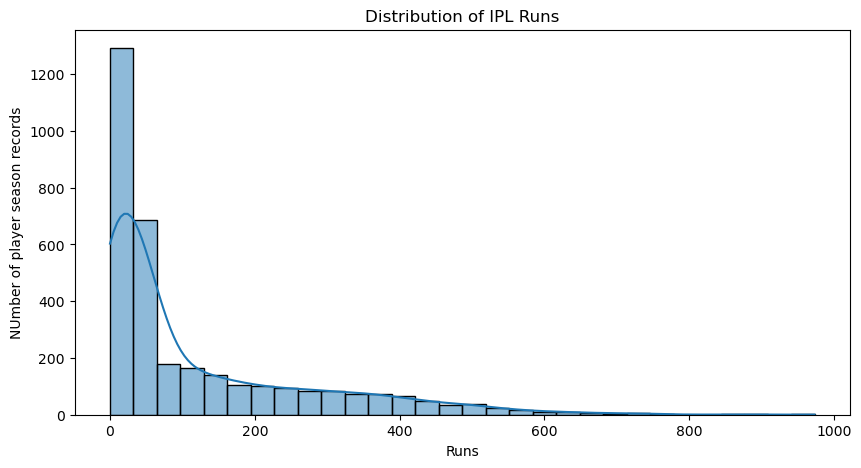

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df["Runs"],bins=30,kde=True)
plt.xlabel("Runs")
plt.ylabel("NUmber of player season records")
plt.title("Distribution of IPL Runs")
plt.show()

In [259]:
#top run scorers
top_run_scorers=df[["Player","Team","Season","Runs"]].sort_values(by="Runs",ascending=False).head(10)

In [260]:
top_run_scorers

,Player,Team,Season,Runs
2786,V Kohli,Royal Challengers Bangalore,2016,973.0
5066,Shubman Gill,Gujarat Titans,2023,890.0
4686,JC Buttler,Rajasthan Royals,2022,863.0
2788,DA Warner,Sunrisers Hyderabad,2016,848.0
6290,V Sooryavanshi,Rajasthan Royals,2026,776.0
5484,V Kohli,Royal Challengers Bengaluru,2024,741.0
3426,KS Williamson,Sunrisers Hyderabad,2018,735.0
1796,MEK Hussey,Chennai Super Kings,2013,733.0
1416,CH Gayle,Royal Challengers Bangalore,2012,733.0
6292,Shubman Gill,Gujarat Titans,2026,732.0


In [262]:
#individual performances to season-level performance.
season_runs=(df.groupby("Season")["Runs"].sum().sort_values(ascending=False))
season_runs

Season
2026    27425.0
2024    26519.0
2023    25996.0
2025    24684.0
2022    23836.0
2013    22554.0
2012    22205.0
2011    20810.0
2018    19588.0
2019    19357.0
2020    19341.0
2016    18893.0
2017    18740.0
2014    18706.0
2021    18500.0
2010    18421.0
2015    18144.0
2008    17201.0
2009    15981.0
Name: Runs, dtype: float64

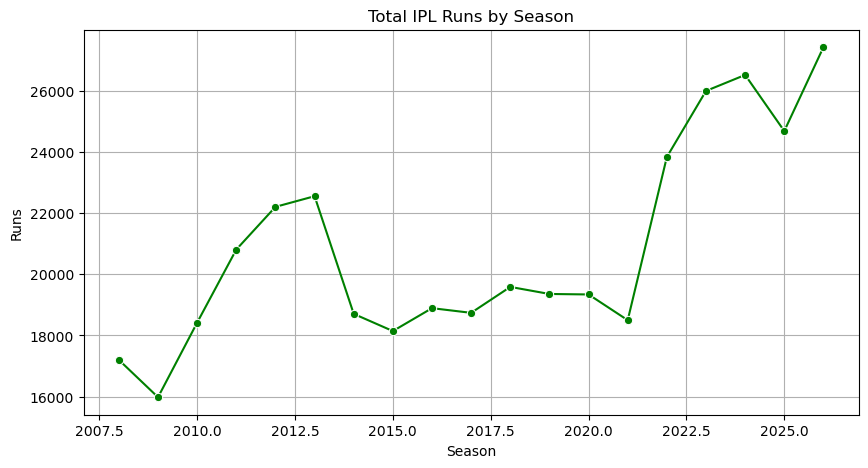

In [269]:
plt.figure(figsize=(10,5))
sns.lineplot(season_runs,marker="o",color="g")
plt.title("Total IPL Runs by Season")
plt.grid()
plt.show()

2026: 27,425 runs — highest in your dataset

2024: 26,519 runs

2023: 25,996 runs

2009: 15,981 runs — lowest

There is a general increase in total runs in the recent seasons.

This is useful for studying how overall batting output has changed across IPL seasons.

In [270]:
#Average runs per player-season
season_avg_runs = (
    df.groupby("Season")["Runs"]
      .mean()
      .sort_values(ascending=False)
)

season_avg_runs

Season
2026    135.767327
2018    131.463087
2020    128.086093
2024    127.495192
2025    126.584615
2022    125.452632
2015    125.131034
2023    124.382775
2014    123.065789
2019    119.487654
2016    118.823899
2012    116.868421
2017    116.397516
2013    113.909091
2021    110.119048
2008    105.527607
2011    104.572864
2010    101.773481
2009     96.854545
Name: Runs, dtype: float64

In [271]:
#Top 10 players by total career runs
top_players_runs = (
    df.groupby("Player")["Runs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_players_runs

Player
V Kohli           9227.0
RG Sharma         7216.0
S Dhawan          6769.0
DA Warner         6565.0
KL Rahul          5815.0
SK Raina          5528.0
MS Dhoni          5439.0
AM Rahane         5367.0
SV Samson         5181.0
AB de Villiers    5162.0
Name: Runs, dtype: float64

V Kohli has the highest cumulative runs followed by RG Sharma and S Dhawan.

this is total runs across all seasons , so players with longer IPL careers naturally have more opportunity to accumulate runs

In [272]:
#Most consistent/high-impact players
player_avg_runs = (
    df.groupby("Player")["Runs"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

player_avg_runs

Player
V Sooryavanshi     514.000000
Shubman Gill       510.777778
CPL Connolly       491.000000
B Sai Sudharsan    487.000000
V Kohli            485.631579
KL Rahul           447.307692
DA Warner          437.666667
SK Raina           425.230769
JC Buttler         422.363636
RD Gaikwad         405.571429
Name: Runs, dtype: float64

In [274]:
#Players with at least 5 seasons
player_season_count = df.groupby("Player")["Season"].nunique()

player_avg_runs_5plus = (
    df.groupby("Player")["Runs"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values(ascending=False)
      .head(10)
)

player_avg_runs_5plus

Player
Shubman Gill       510.777778
B Sai Sudharsan    487.000000
V Kohli            485.631579
KL Rahul           447.307692
DA Warner          437.666667
SK Raina           425.230769
JC Buttler         422.363636
RD Gaikwad         405.571429
S Dhawan           398.176471
SR Tendulkar       389.000000
Name: Runs, dtype: float64

Team performance

In [280]:
df["Team"] = df["Team"].replace({
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
})

In [281]:
df["Team"].value_counts()

Team
Royal Challengers Bengaluru    389
Mumbai Indians                 383
Kolkata Knight Riders          370
Rajasthan Royals               348
Chennai Super Kings            318
Sunrisers Hyderabad            278
Kings XI Punjab                264
Delhi Daredevils               225
Delhi Capitals                 166
Punjab Kings                   123
Lucknow Super Giants           104
Deccan Chargers                103
Gujarat Titans                  96
Pune Warriors                   74
Gujarat Lions                   43
Rising Pune Supergiants         43
Kochi Tuskers Kerala            20
Name: count, dtype: int64

In [282]:
team_runs = (
    df.groupby("Team")["Runs"]
      .sum()
      .sort_values(ascending=False)
)

team_runs

Team
Mumbai Indians                 46539.0
Royal Challengers Bengaluru    45317.0
Chennai Super Kings            44032.0
Kolkata Knight Riders          43025.0
Rajasthan Royals               40056.0
Sunrisers Hyderabad            34453.0
Kings XI Punjab                29721.0
Delhi Daredevils               23991.0
Delhi Capitals                 19805.0
Punjab Kings                   14773.0
Gujarat Titans                 13738.0
Lucknow Super Giants           12633.0
Deccan Chargers                11228.0
Pune Warriors                   6236.0
Gujarat Lions                   5019.0
Rising Pune Supergiants         4528.0
Kochi Tuskers Kerala            1807.0
Name: Runs, dtype: float64

In [283]:
#Team average runs
team_avg_runs = (
    df.groupby("Team")["Runs"]
      .mean()
      .sort_values(ascending=False)
)

team_avg_runs

Team
Gujarat Titans                 143.104167
Chennai Super Kings            138.465409
Sunrisers Hyderabad            123.931655
Mumbai Indians                 121.511749
Lucknow Super Giants           121.471154
Punjab Kings                   120.105691
Delhi Capitals                 119.307229
Gujarat Lions                  116.720930
Royal Challengers Bengaluru    116.496144
Kolkata Knight Riders          116.283784
Rajasthan Royals               115.103448
Kings XI Punjab                112.579545
Deccan Chargers                109.009709
Delhi Daredevils               106.626667
Rising Pune Supergiants        105.302326
Kochi Tuskers Kerala            90.350000
Pune Warriors                   84.270270
Name: Runs, dtype: float64

Mumbai Indians has the highest total runs.
Gujarat Titans has the highest average runs per team-season record.

That's because total runs are strongly affected by how many seasons/records a team has, while the average gives us a different view of scoring output.

Team-wise average batting strike rate

In [284]:
team_avg_sr = (
    df.groupby("Team")["Strike_Rate"]
      .mean()
      .sort_values(ascending=False)
)

team_avg_sr

Team
Punjab Kings                   126.250488
Gujarat Titans                 117.893958
Chennai Super Kings            117.475503
Lucknow Super Giants           116.738462
Sunrisers Hyderabad            116.083094
Delhi Capitals                 115.438614
Kolkata Knight Riders          112.848270
Royal Challengers Bengaluru    112.779254
Mumbai Indians                 112.580601
Rajasthan Royals               109.020144
Kings XI Punjab                108.967348
Rising Pune Supergiants        108.935814
Gujarat Lions                  106.733721
Delhi Daredevils               103.848844
Deccan Chargers                103.206019
Kochi Tuskers Kerala           100.911500
Pune Warriors                   99.447703
Name: Strike_Rate, dtype: float64

Key observations:

Punjab Kings: 126.25 — highest average Strike Rate

Gujarat Titans: 117.89

Chennai Super Kings: 117.48

Lucknow Super Giants: 116.74

Sunrisers Hyderabad: 116.08

Royal Challengers Bengaluru: 112.78

Mumbai Indians: 112.58

Pune Warriors: 99.45 — lowest

One important point: this is the mean of player-level Strike_Rate values, not the team's overall strike rate

Player consistency

In [285]:
player_avg_batting = (
    df.groupby("Player")["Batting_Average"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values(ascending=False)
      .head(10)
)

player_avg_batting

Player
B Sai Sudharsan    46.642000
JP Duminy          42.676250
KL Rahul           42.517692
MS Dhoni           41.100000
V Kohli            40.936842
KP Pietersen       40.280000
Shubman Gill       40.115556
JC Buttler         39.625455
DA Warner          39.542000
MEK Hussey         38.705714
Name: Batting_Average, dtype: float64

Relationship between Runs and Strike Rate

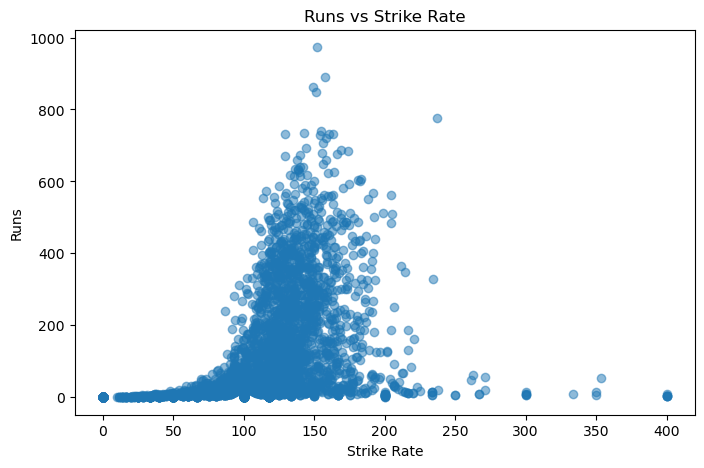

In [286]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Strike_Rate"], df["Runs"], alpha=0.5)

plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.title("Runs vs Strike Rate")

plt.show()

In [287]:
#the 100–150 strike-rate range contains many of the higher-run player-season records.

In [288]:
#Correlation
df[["Runs","Strike_Rate"]].corr()

,Runs,Strike_Rate
Runs,1.000000,0.416261
Strike_Rate,0.416261,1.000000


In [289]:
team_total_runs = (
    df.groupby("Team")["Runs"]
      .sum()
      .sort_values(ascending=False)
)

team_total_runs

Team
Mumbai Indians                 46539.0
Royal Challengers Bengaluru    45317.0
Chennai Super Kings            44032.0
Kolkata Knight Riders          43025.0
Rajasthan Royals               40056.0
Sunrisers Hyderabad            34453.0
Kings XI Punjab                29721.0
Delhi Daredevils               23991.0
Delhi Capitals                 19805.0
Punjab Kings                   14773.0
Gujarat Titans                 13738.0
Lucknow Super Giants           12633.0
Deccan Chargers                11228.0
Pune Warriors                   6236.0
Gujarat Lions                   5019.0
Rising Pune Supergiants         4528.0
Kochi Tuskers Kerala            1807.0
Name: Runs, dtype: float64

Insight: Mumbai Indians has the highest cumulative runs in our cleaned 2008–2026 dataset. This is a volume measure, so teams with more seasons/records naturally have more opportunity to accumulate runs.

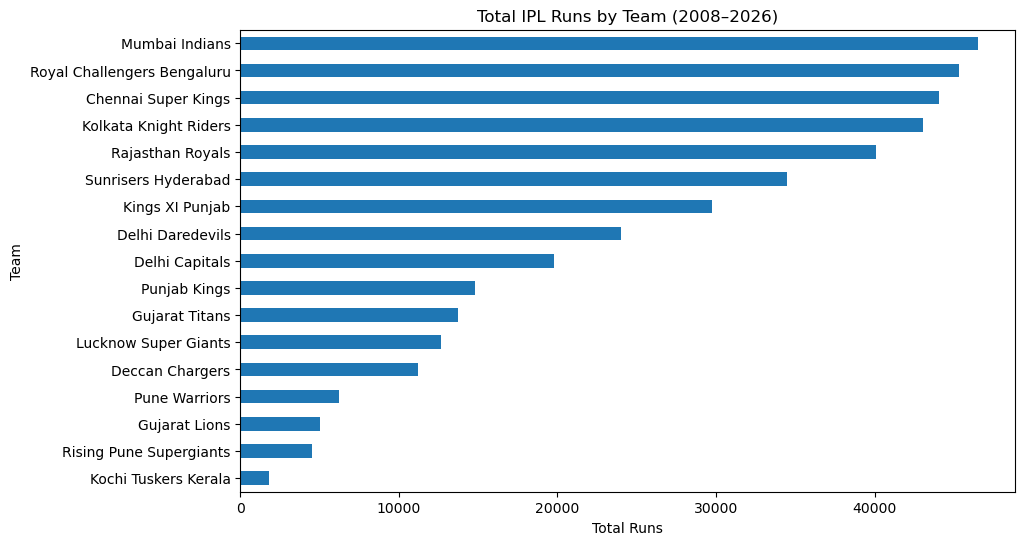

In [290]:
#Team Run Distribution
plt.figure(figsize=(10, 6))

team_total_runs.sort_values().plot(kind="barh")

plt.xlabel("Total Runs")
plt.ylabel("Team")
plt.title("Total IPL Runs by Team (2008–2026)")

plt.show()

In [292]:
#Top Players by Batting Average
top_batting_average = (
    df.groupby("Player")["Batting_Average"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values(ascending=False)
      .head(10)
)

top_batting_average
#This gives us the top 10 players by average batting average among players with at least 5 seasons.

Player
B Sai Sudharsan    46.642000
JP Duminy          42.676250
KL Rahul           42.517692
MS Dhoni           41.100000
V Kohli            40.936842
KP Pietersen       40.280000
Shubman Gill       40.115556
JC Buttler         39.625455
DA Warner          39.542000
MEK Hussey         38.705714
Name: Batting_Average, dtype: float64

In [293]:
#Top Players by Strike Rate
top_strike_rate = (
    df.groupby("Player")["Strike_Rate"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values(ascending=False)
      .head(10)
)

top_strike_rate

Player
R Shepherd         178.392000
AN Ahmed           171.830000
TM Head            159.816000
Abhishek Sharma    158.635556
BCJ Cutting        158.408000
Harpreet Brar      158.131250
N Pooran           157.590000
TH David           156.628333
RM Patidar         155.050000
LH Ferguson        154.441111
Name: Strike_Rate, dtype: float64

In [301]:
#Centuries & Fifties
print("\nPlayers With most Centuries:")
top_centuries = (
    df.groupby("Player")["Centuries"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_fifties = (
    df.groupby("Player")["Fifties"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_centuries


Players With most Centuries:


Player
V Kohli            9.0
JC Buttler         7.0
CH Gayle           6.0
KL Rahul           6.0
Shubman Gill       5.0
SV Samson          5.0
SR Watson          4.0
DA Warner          4.0
B Sai Sudharsan    3.0
AB de Villiers     3.0
Name: Centuries, dtype: float64

In [300]:
print("\nPlayers with most 50's:")
top_fifties


Players with most 50's:


Player
V Kohli           67.0
DA Warner         62.0
S Dhawan          51.0
RG Sharma         48.0
KL Rahul          45.0
AB de Villiers    40.0
F du Plessis      39.0
SK Raina          39.0
G Gambhir         36.0
AM Rahane         35.0
Name: Fifties, dtype: float64

This gives us two useful measures of high-impact batting performances:

Centuries → number of 100+ scores
Fifties → number of 50–99 scores

Together, they show how frequently players produced major individual innings.

In [305]:
print("Most fours by players:")
top_fours = (
    df.groupby("Player")["Fours"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_fours

Most fours by players:


Player
V Kohli       829.0
S Dhawan      768.0
DA Warner     663.0
RG Sharma     649.0
AM Rahane     539.0
KL Rahul      508.0
SK Raina      506.0
G Gambhir     492.0
RV Uthappa    481.0
SA Yadav      471.0
Name: Fours, dtype: float64

In [306]:
print("Most sixes by players:")
top_sixes = (
    df.groupby("Player")["Sixes"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_sixes
#This tells us which players contributed most through boundaries, giving us another view of attacking batting.

Most sixes by players:


Player
CH Gayle          357.0
RG Sharma         318.0
V Kohli           316.0
MS Dhoni          264.0
AB de Villiers    251.0
SV Samson         243.0
KL Rahul          239.0
DA Warner         236.0
KA Pollard        223.0
AD Russell        223.0
Name: Sixes, dtype: float64

Season-wise Batting Trend

In [307]:
season_batting_trend = (
    df.groupby("Season")
      .agg(
          Total_Runs=("Runs", "sum"),
          Average_Runs=("Runs", "mean"),
          Average_Strike_Rate=("Strike_Rate", "mean")
      )
)

season_batting_trend

,Total_Runs,Average_Runs,Average_Strike_Rate
Season,,,
2008,17201.0,105.527607,106.899325
2009,15981.0,96.854545,98.034545
2010,18421.0,101.773481,104.932155
2011,20810.0,104.572864,102.111005
2012,22205.0,116.868421,110.219579
2013,22554.0,113.909091,103.053838
2014,18706.0,123.065789,111.624211
2015,18144.0,125.131034,116.889517
2016,18893.0,118.823899,115.447358


Player Consistency

In [308]:
player_consistency = (
    df.groupby("Player")["Runs"]
      .agg(["mean", "std", "count"])
      .query("count >= 5")
      .sort_values("std")
      .head(10)
)

player_consistency

,mean,std,count
Player,,,
M Pathirana,49.000000,0.000000,5
K Khejroliya,49.000000,0.000000,5
VG Arora,2.000000,2.000000,5
SK Trivedi,7.000000,7.014271,6
Ravi Bishnoi,6.428571,7.590721,7
NM Coulter-Nile,10.250000,8.940278,8
DL Vettori,34.000000,9.433981,5
MJ McClenaghan,17.000000,9.721111,5
S Sreesanth,6.800000,11.454257,5


We measured consistency using standard deviation of runs for players with at least 5 seasons.

One important point: a low standard deviation alone doesn't mean a player scored a lot — it only means their season-to-season runs were relatively stable.

Outlier Analysis

In [309]:
Q1 = df["Runs"].quantile(0.25)
Q3 = df["Runs"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

run_outliers = df[
    (df["Runs"] < lower_limit) |
    (df["Runs"] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(run_outliers))

Lower Limit: -244.0
Upper Limit: 436.0
Number of Outliers: 184


In [310]:
print("Highest Total Runs by a Player:",
      df.groupby("Player")["Runs"].sum().idxmax())

print("Highest Total Runs:",
      df.groupby("Player")["Runs"].sum().max())

print("Highest Runs in a Single Season:",
      df["Runs"].max())

print("Highest Run-Scoring Season:",
      df.groupby("Season")["Runs"].sum().idxmax())

print("Highest Team Total Runs:",
      df.groupby("Team")["Runs"].sum().idxmax())

print("Runs–Strike Rate Correlation:",
      df[["Runs", "Strike_Rate"]].corr().loc["Runs", "Strike_Rate"])

Highest Total Runs by a Player: V Kohli
Highest Total Runs: 9227.0
Highest Runs in a Single Season: 973.0
Highest Run-Scoring Season: 2026
Highest Team Total Runs: Mumbai Indians
Runs–Strike Rate Correlation: 0.4162607637883399


Data Visualization

Total IPL Runs by Season

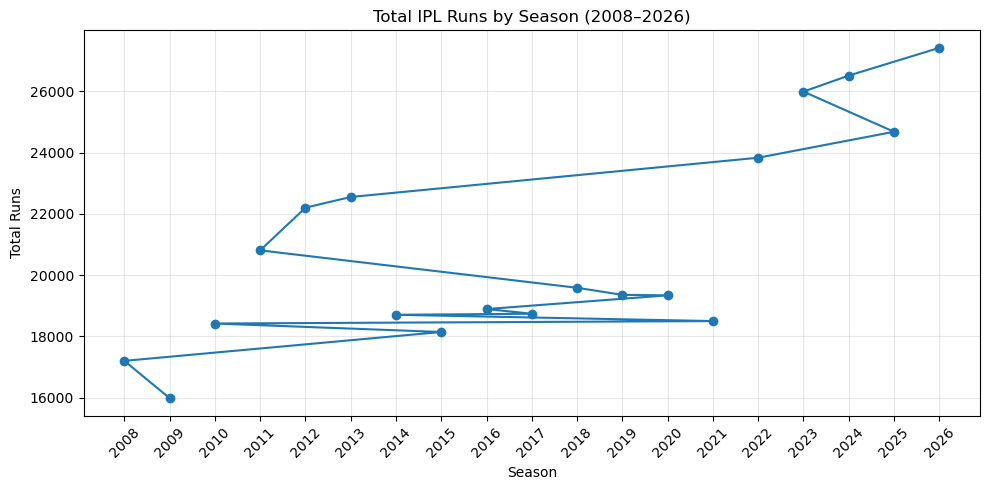

In [311]:
plt.figure(figsize=(10, 5))

plt.plot(
    season_runs.index,
    season_runs.values,
    marker="o"
)

plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.title("Total IPL Runs by Season (2008–2026)")

plt.xticks(season_runs.index, rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Top 10 Players by Career Runs

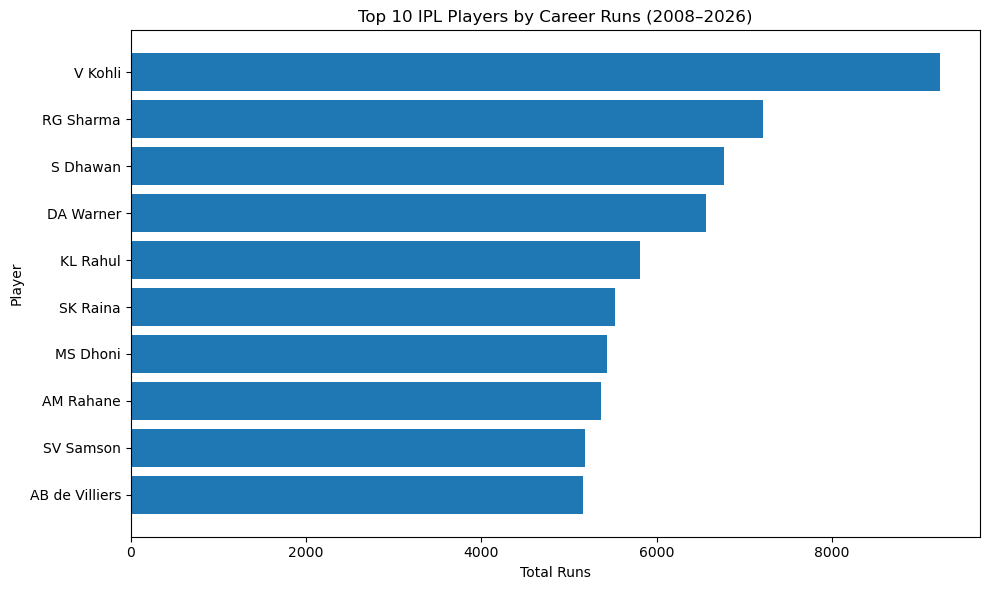

In [312]:
top_10_career_runs = (
    df.groupby("Player")["Runs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_career_runs.index,
    top_10_career_runs.values
)

plt.xlabel("Total Runs")
plt.ylabel("Player")
plt.title("Top 10 IPL Players by Career Runs (2008–2026)")

plt.tight_layout()
plt.show()

Top 10 Players by Batting Average

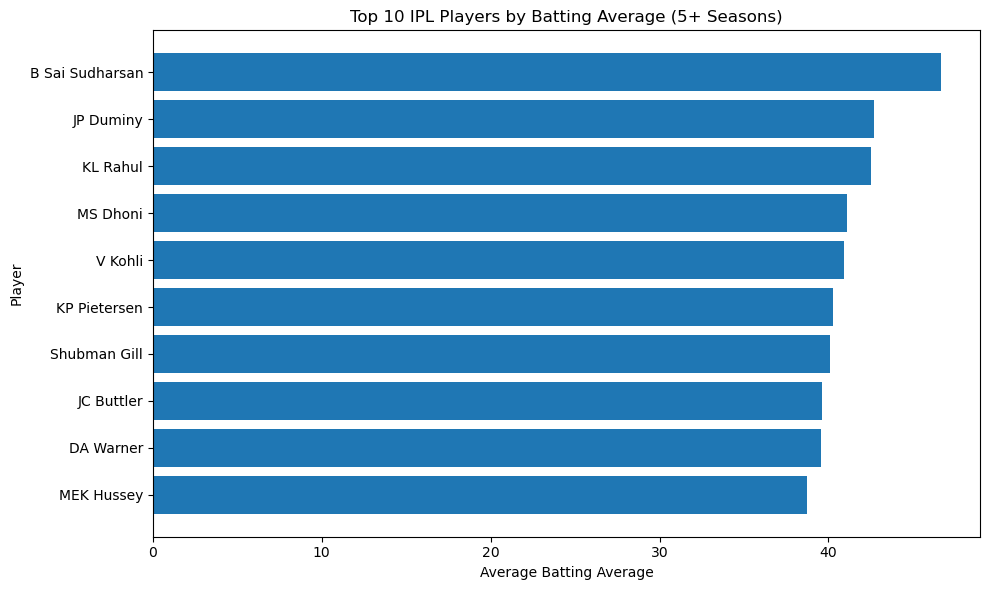

In [313]:
top_10_batting_average = (
    df.groupby("Player")["Batting_Average"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values()
      .tail(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_batting_average.index,
    top_10_batting_average.values
)

plt.xlabel("Average Batting Average")
plt.ylabel("Player")
plt.title("Top 10 IPL Players by Batting Average (5+ Seasons)")

plt.tight_layout()
plt.show()

Top 10 Players by Strike Rate

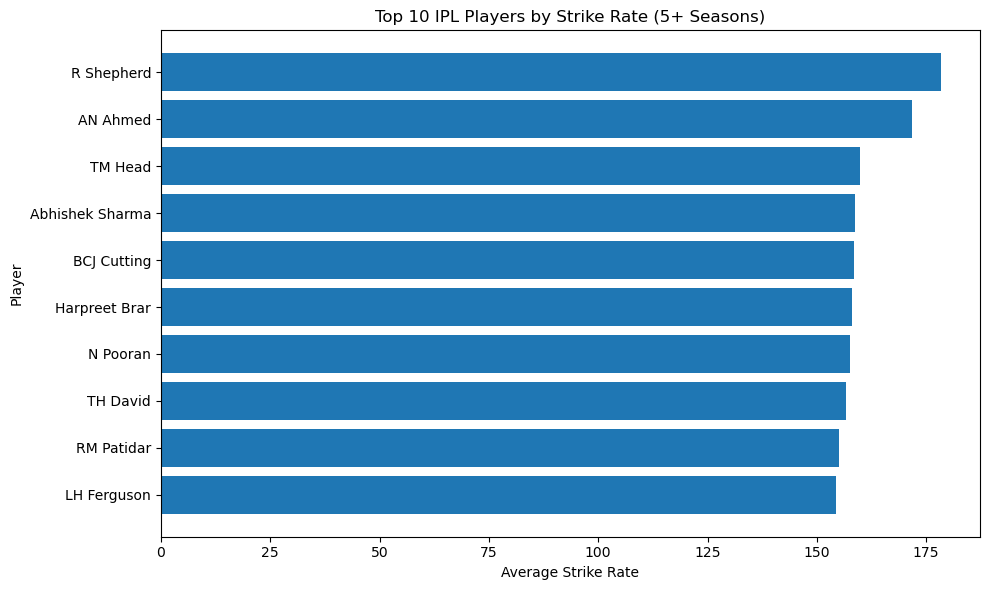

In [314]:
top_10_strike_rate = (
    df.groupby("Player")["Strike_Rate"]
      .mean()
      .loc[player_season_count >= 5]
      .sort_values()
      .tail(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_strike_rate.index,
    top_10_strike_rate.values
)

plt.xlabel("Average Strike Rate")
plt.ylabel("Player")
plt.title("Top 10 IPL Players by Strike Rate (5+ Seasons)")

plt.tight_layout()
plt.show()

Centuries & Fifties

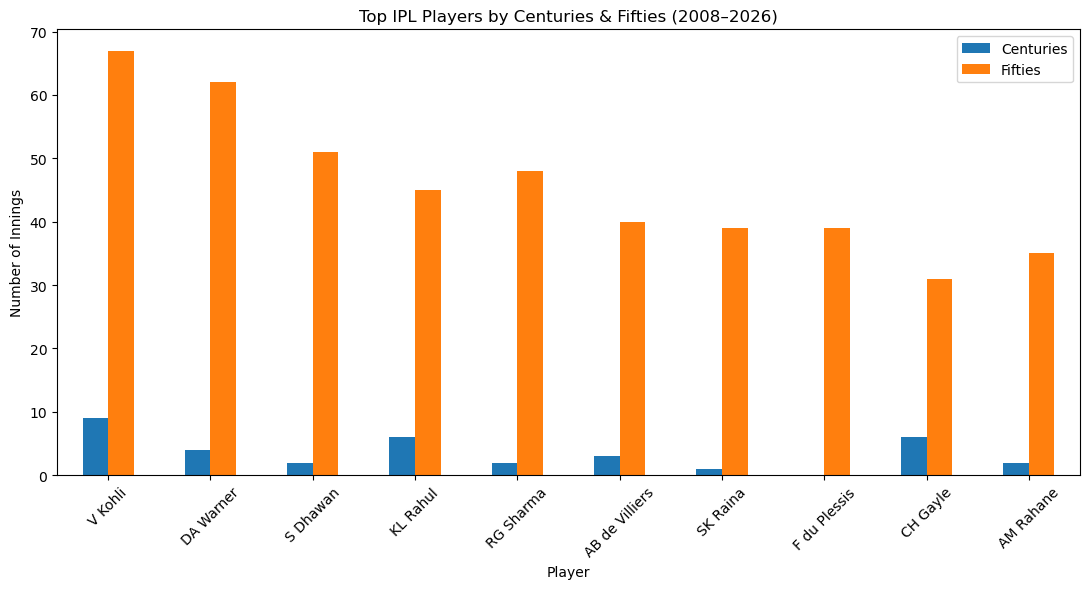

In [317]:
top_10_milestones = (
    df.groupby("Player")[["Centuries", "Fifties"]]
      .sum()
      .sum(axis=1)
      .sort_values(ascending=False)
      .head(10)
      .index
)

milestones = (
    df.groupby("Player")[["Centuries", "Fifties"]]
      .sum()
      .loc[top_10_milestones]
)

milestones.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Player")
plt.ylabel("Number of Innings")
plt.title("Top IPL Players by Centuries & Fifties (2008–2026)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

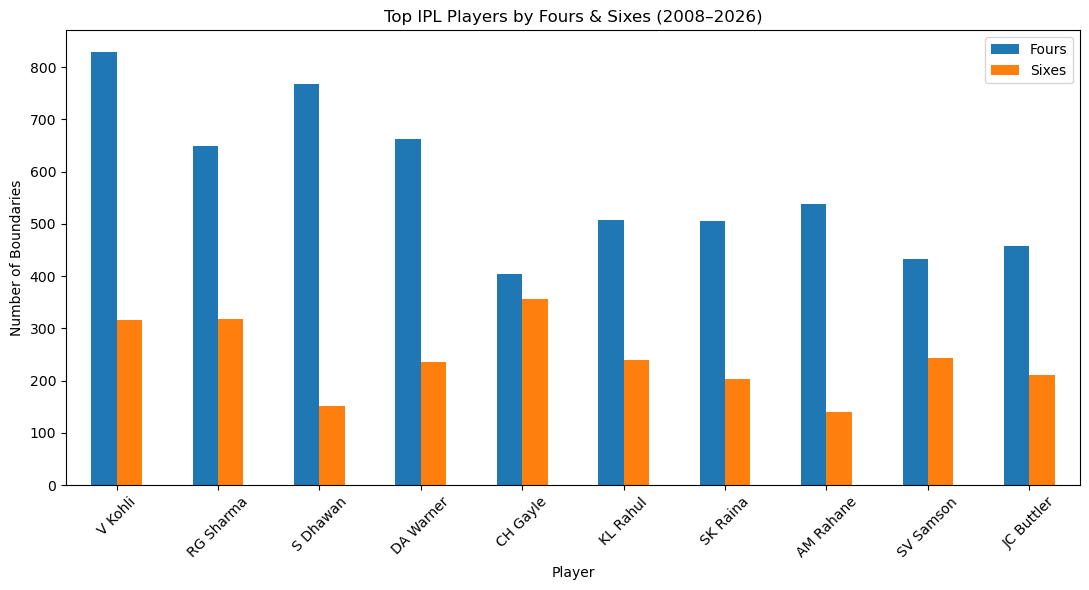

In [318]:
#Fours & Sixes
top_10_boundaries = (
    df.groupby("Player")[["Fours", "Sixes"]]
      .sum()
      .sum(axis=1)
      .sort_values(ascending=False)
      .head(10)
      .index
)

boundaries = (
    df.groupby("Player")[["Fours", "Sixes"]]
      .sum()
      .loc[top_10_boundaries]
)

boundaries.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Player")
plt.ylabel("Number of Boundaries")
plt.title("Top IPL Players by Fours & Sixes (2008–2026)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

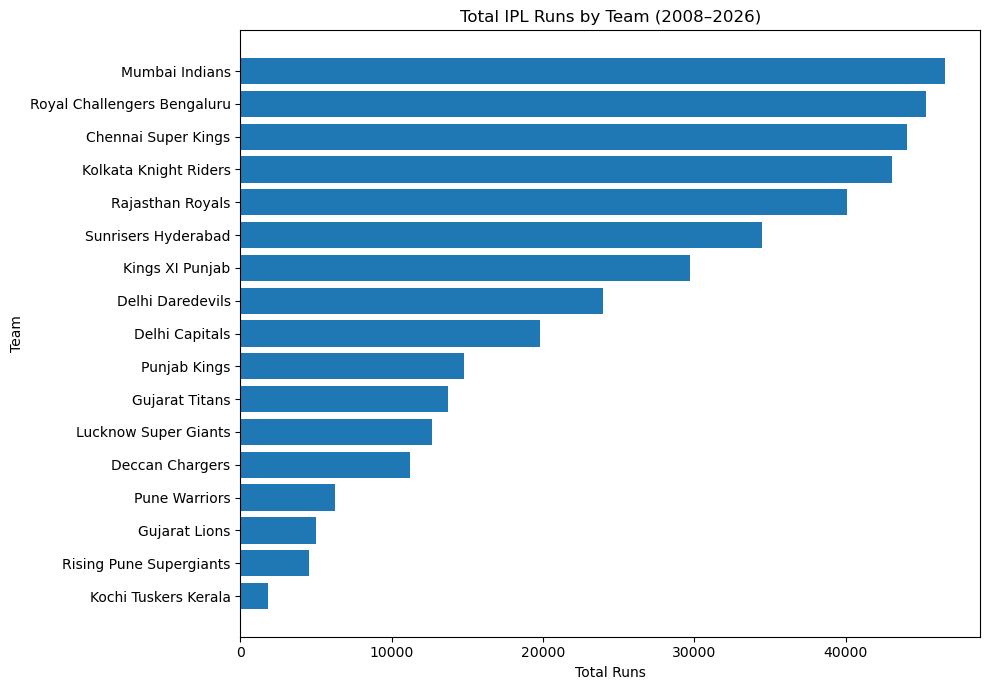

In [319]:
#Team-wise Total Runs
team_total_runs = (
    df.groupby("Team")["Runs"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 7))

plt.barh(
    team_total_runs.index,
    team_total_runs.values
)

plt.xlabel("Total Runs")
plt.ylabel("Team")
plt.title("Total IPL Runs by Team (2008–2026)")

plt.tight_layout()
plt.show()

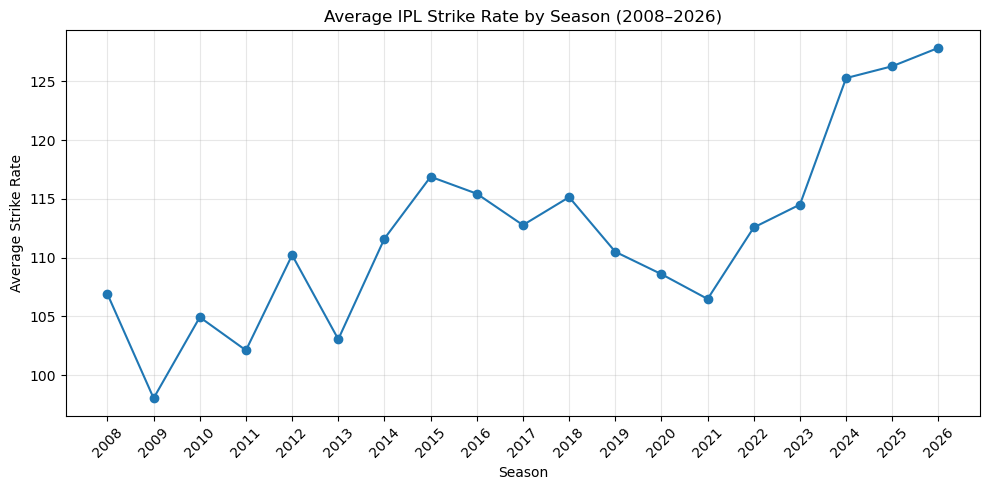

In [320]:
#Season-wise Average Strike Rate
season_avg_sr = (
    df.groupby("Season")["Strike_Rate"]
      .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    season_avg_sr.index,
    season_avg_sr.values,
    marker="o"
)

plt.xlabel("Season")
plt.ylabel("Average Strike Rate")
plt.title("Average IPL Strike Rate by Season (2008–2026)")

plt.xticks(season_avg_sr.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

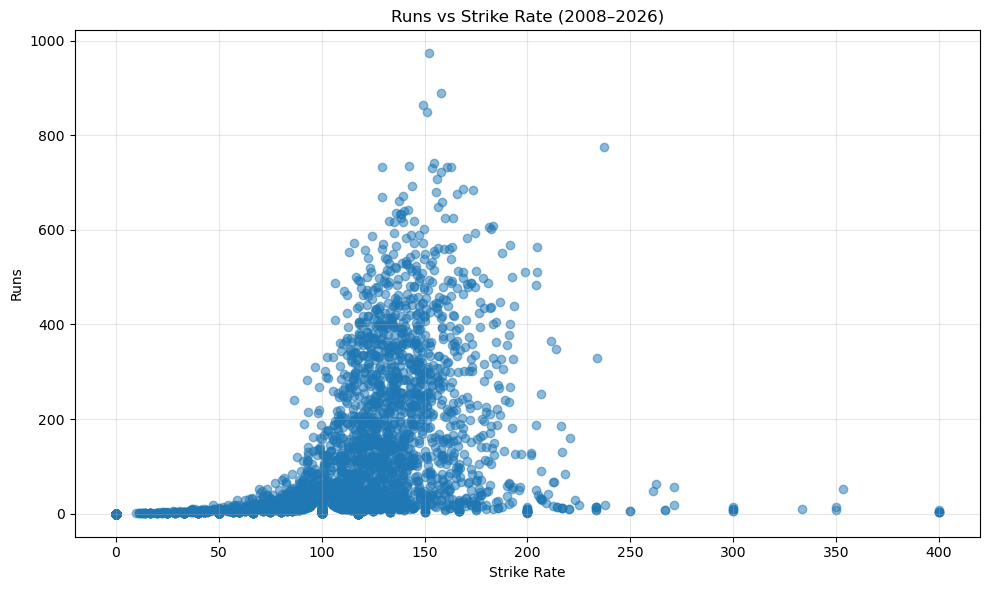

In [321]:
#Runs vs Strike Rate
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Strike_Rate"],
    df["Runs"],
    alpha=0.5
)

plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.title("Runs vs Strike Rate (2008–2026)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Insights

Insight 1:  Overall Run Production:

From our analysis of IPL batting data from 2008–2026:

V Kohli has the highest cumulative runs in our dataset: 9,227.

Mumbai Indians has the highest cumulative team runs: 46,539.

2026 has the highest total runs by season: 27,425.

2009 has the lowest total runs: 15,981.

IPL batting output has increased substantially in recent seasons, while a small group of long-term players accounts for a large share of cumulative runs.

Insight 2 — Runs & Strike Rate:

Our correlation analysis found:

Runs ↔ Strike Rate = 0.416

What it means

There is a moderate positive relationship between strike rate and runs in our dataset.

Players with higher strike rates tend to score more runs, but strike rate alone does not explain total run production.

High scoring in IPL is associated with faster scoring, but sustained run production depends on more than strike rate alone.

Insight 3 — Team Performance:

Mumbai Indians — 46,539 runs

Royal Challengers Bengaluru — 45,317

Chennai Super Kings — 44,032

Kolkata Knight Riders — 43,025

A small group of long-running IPL teams accounts for a large share of cumulative batting runs, reflecting both sustained participation and batting output over multiple seasons.

Insight 4 — Batting Milestones & Boundaries:

Our analysis of Centuries, Fifties, Fours, and Sixes gives another view of batting impact.

IPL batting impact is not measured only by total runs; repeated 50+ scores and boundary contributions provide additional evidence of a player's ability to produce impactful innings.

Insight 5 — Season-wise Batting Trends:

From our season analysis:

2026 had the highest total runs: 27,425

2009 had the lowest: 15,981

2026 also had the highest average runs per player-season: 135.77

Recent seasons generally show higher batting output than the early IPL seasons.

Overall batting output has increased across the IPL seasons, with recent seasons showing higher run production than the early years.

Insight 6 — Player Consistency

We measured consistency using the standard deviation of runs for players with at least 5 seasons.

What it means

Lower standard deviation → runs are more stable across seasons.

Higher standard deviation → larger variation between seasons.

Long-term IPL performance should be evaluated not only by total runs but also by how consistently a player produces runs across seasons.

Insight 7 — Exceptional Performances

Our outlier analysis using the IQR method identified player-season records that are unusually high or low compared with the overall distribution.

These records should not automatically be removed, because an unusually high score can represent a genuine exceptional sporting performance.

Extreme batting performances are meaningful in sports analytics and should be investigated rather than automatically treated as data errors.

Final Business Insights & Recommendations:

Key Insights:

Increasing batting output:
Recent IPL seasons show higher overall run production compared with the early seasons, with 2026 recording 27,425 total runs in the cleaned dataset.

Long-term player contribution:
V Kohli recorded the highest cumulative runs (9,227) in our dataset, demonstrating the importance of sustained performance over multiple seasons.

Strike rate and run production:
Runs and strike rate have a moderate positive correlation of 0.416, indicating that faster scoring is associated with higher run totals, although strike rate alone does not determine total runs.

Team batting contribution:
Mumbai Indians, Royal Challengers Bengaluru, Chennai Super Kings and Kolkata Knight Riders recorded the highest cumulative team runs in the dataset.

Multiple dimensions of batting performance:
Total runs, batting average, strike rate, centuries, fifties, fours and sixes provide different perspectives on player performance. No single metric captures every aspect of batting.

Consistency matters:
Standard deviation of seasonal runs can help distinguish players with relatively stable output from players whose performances vary considerably between seasons.

Exceptional performances:
IQR analysis identified unusually high/low run records. These should be investigated rather than automatically removed because extreme sporting performances can be genuine.

Recommendations:
For team management:
Consider multiple batting metrics rather than relying only on total runs when evaluating players.

For player analysis: 
Combine run volume, batting average, strike rate and consistency to understand overall performance.

For scouting: 
Use multi-season performance rather than a single exceptional season as one input when assessing players.

For performance monitoring: 
Track season-wise trends to identify changes in batting output and scoring rates.

For analysts: 
Treat genuine exceptional performances separately from data-quality errors during outlier analysis.